# Correlation analysis

COMPREHENSIVE CORRELATION ANALYSIS

Configuration:
  Data file: model-data.xlsx
  Output directory: correlation_analysis_outputs
  Correlation threshold: |ρ| ≥ 0.3
  FDR significance level: α = 0.05
  Minimum pairwise samples: 20

--------------------------------------------------------------------------------
LOADING DATA
--------------------------------------------------------------------------------
Loaded X (features): (200, 9)
Loaded Y (endpoints): (200, 6)
Sample IDs match: True

Using:
  Numerical features: 3
  Categorical features: 6
  Endpoints: 6

ANALYSIS 1: FEATURE-TO-ENDPOINT CORRELATIONS

Total encoded features: 39
  - Numerical: 3
  - Categorical (one-hot): 36

Strong correlations (|ρ| ≥ 0.3): 3 / 234 (1.3%)

✓ Saved: correlation_analysis_outputs\FIG1_feature_endpoint_correlations.png


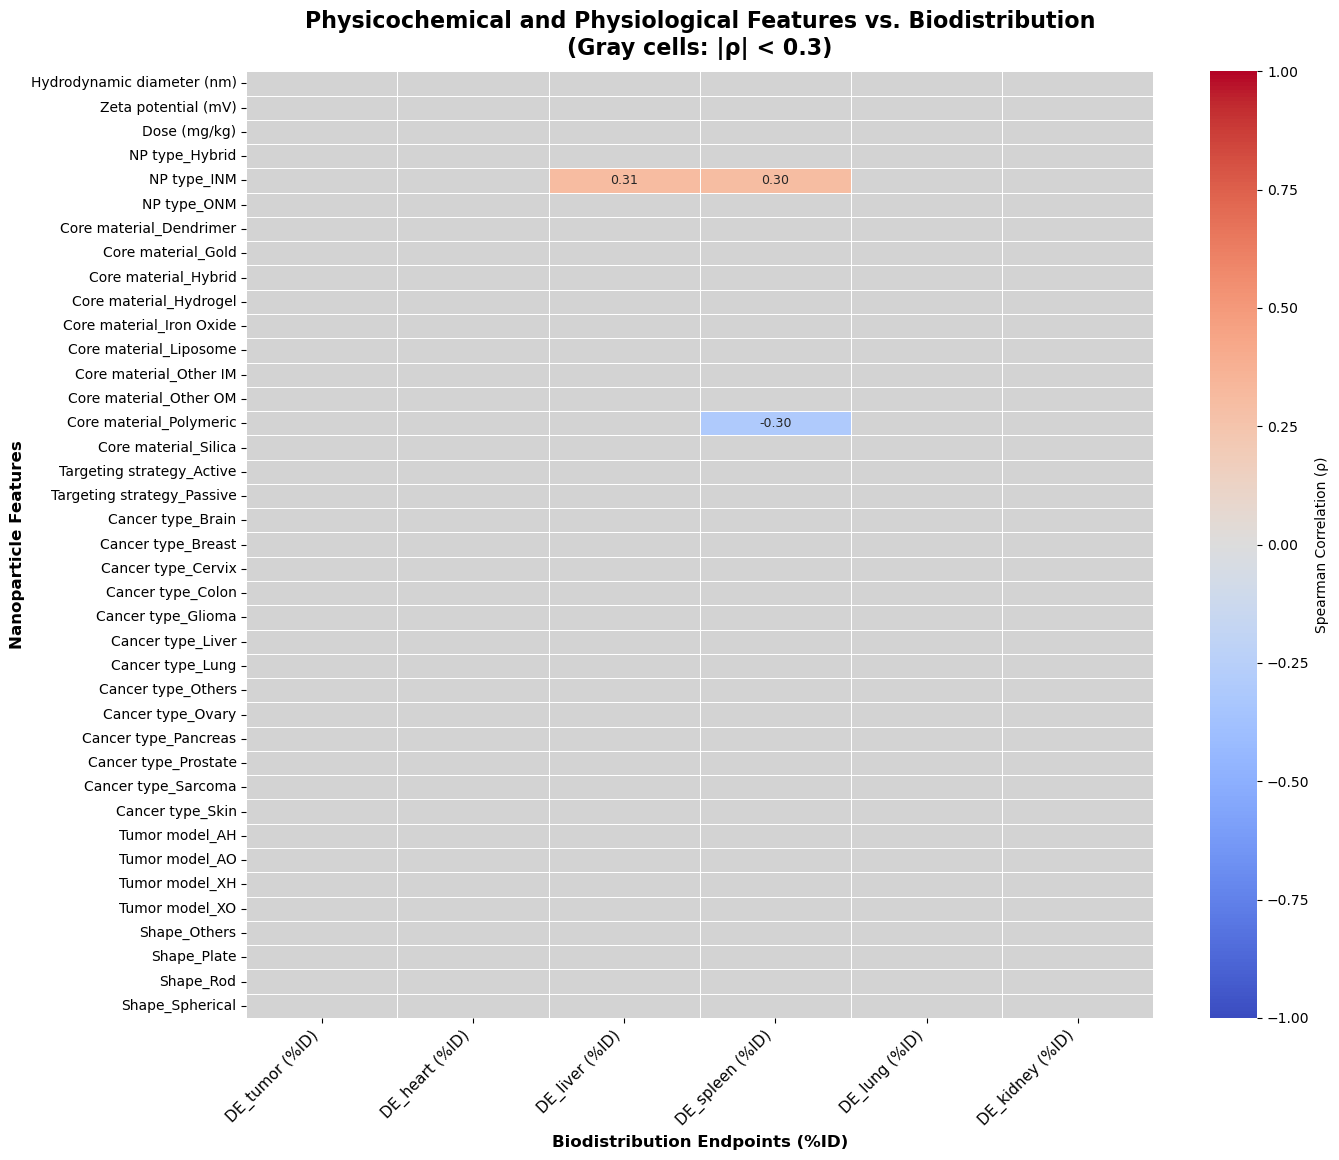


Top 10 strongest feature-endpoint correlations:
--------------------------------------------------------------------------------
 1. NP type_INM                              → DE_liver (%ID)        ρ = +0.309
 2. Core material_Polymeric                  → DE_spleen (%ID)       ρ = -0.301
 3. NP type_INM                              → DE_spleen (%ID)       ρ = +0.300
 4. Tumor model_XO                           → DE_liver (%ID)        ρ = -0.294
 5. Core material_Polymeric                  → DE_liver (%ID)        ρ = -0.292
 6. NP type_ONM                              → DE_liver (%ID)        ρ = -0.266
 7. NP type_ONM                              → DE_spleen (%ID)       ρ = -0.265
 8. Core material_Gold                       → DE_spleen (%ID)       ρ = +0.261
 9. Shape_Rod                                → DE_liver (%ID)        ρ = +0.250
10. Shape_Spherical                          → DE_liver (%ID)        ρ = -0.250

ANALYSIS 2: ENDPOINT-TO-ENDPOINT CORRELATIONS

✓ Saved: correlation_a

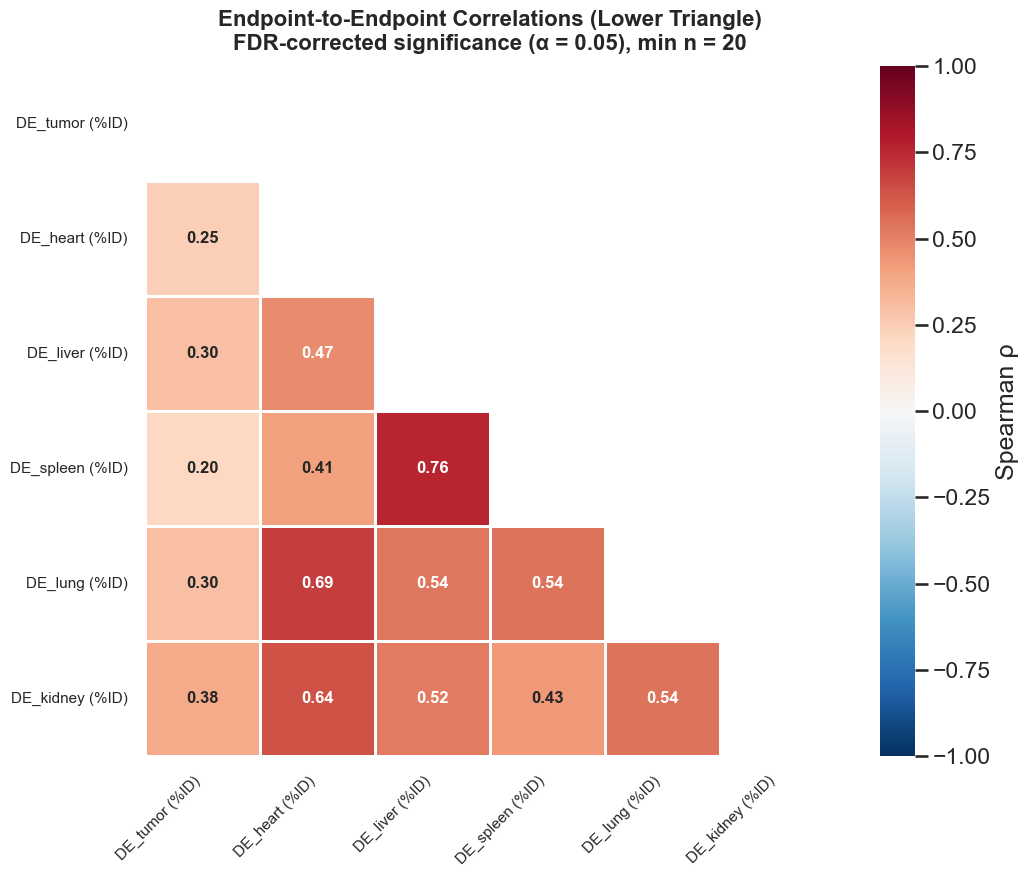


Significant endpoint pairs (FDR < 0.05): 15 / 15

Top 5 strongest significant correlations:
--------------------------------------------------------------------------------
  DE_liver (%ID)       ↔ DE_spleen (%ID)       ρ = +0.764, q = 0.0000
  DE_heart (%ID)       ↔ DE_lung (%ID)         ρ = +0.690, q = 0.0000
  DE_heart (%ID)       ↔ DE_kidney (%ID)       ρ = +0.638, q = 0.0000
  DE_lung (%ID)        ↔ DE_kidney (%ID)       ρ = +0.542, q = 0.0000
  DE_spleen (%ID)      ↔ DE_lung (%ID)         ρ = +0.540, q = 0.0000

ANALYSIS 3: NUMERICAL DRIVERS-TO-ENDPOINT CORRELATIONS

✓ Saved: correlation_analysis_outputs\FIG3_drivers_endpoint_correlations_FDR.png


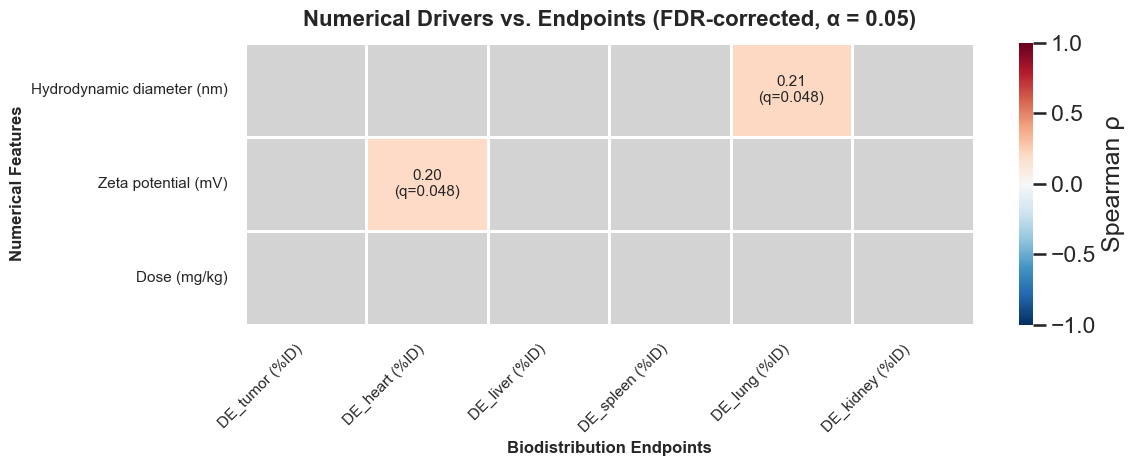


Significant driver-endpoint pairs (FDR < 0.05): 2 / 18

CORRELATION ANALYSIS COMPLETE

All outputs saved to: correlation_analysis_outputs/

Generated files:
  Figures:
    - FIG1_feature_endpoint_correlations.png
    - FIG2_endpoint_correlations_triangle.png
    - FIG3_drivers_endpoint_correlations_FDR.png

  Tables:
    - TABLE1_feature_endpoint_correlations.xlsx
    - TABLE2_endpoint_correlations.xlsx
    - TABLE3_drivers_endpoint_correlations.xlsx



In [1]:
# ==============================================================================
# COMPREHENSIVE CORRELATION ANALYSIS - SUPPLEMENTARY CODE
# For manuscript: "Are similar nanoforms comparable in biodistribution?"
# ==============================================================================

"""
Complete correlation analysis workflow for nanoparticle biodistribution study.
Analyzes three types of relationships:
  1. Feature-to-Endpoint correlations (physicochemical → biodistribution)
  2. Endpoint-to-Endpoint correlations (tissue co-distribution patterns)
  3. Numerical Driver-to-Endpoint correlations (size, zeta, dose effects)

Input: model-data.xlsx
  - X sheet: Features (numerical + categorical)
  - Y sheet: Endpoints (biodistribution %ID values)

Output: High-resolution figures and Excel tables with FDR-corrected p-values
"""

# -------------------------
# 1. IMPORT LIBRARIES
# -------------------------
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

print("="*80)
print("COMPREHENSIVE CORRELATION ANALYSIS")
print("="*80)

# -------------------------
# 2. CONFIGURATION
# -------------------------
FILENAME = "model-data.xlsx"
X_SHEET = "X"
Y_SHEET = "Y"
OUTDIR = "correlation_analysis_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# Feature definitions
NUMERICAL_COLS = [
    "Hydrodynamic diameter (nm)", 
    "Zeta potential (mV)", 
    "Dose (mg/kg)"
]

CATEGORICAL_COLS = [
    "NP type", 
    "Core material", 
    "Targeting strategy", 
    "Cancer type", 
    "Tumor model", 
    "Shape"
]

ENDPOINT_COLS = [
    "DE_tumor (%ID)", 
    "DE_heart (%ID)", 
    "DE_liver (%ID)",
    "DE_spleen (%ID)", 
    "DE_lung (%ID)", 
    "DE_kidney (%ID)"
]

# Statistical settings
THRESHOLD = 0.30        # Correlation threshold for display
ALPHA = 0.05            # FDR significance level
MIN_PAIRWISE_N = 20     # Minimum overlapping samples for valid correlation

print(f"\nConfiguration:")
print(f"  Data file: {FILENAME}")
print(f"  Output directory: {OUTDIR}")
print(f"  Correlation threshold: |ρ| ≥ {THRESHOLD}")
print(f"  FDR significance level: α = {ALPHA}")
print(f"  Minimum pairwise samples: {MIN_PAIRWISE_N}")

# -------------------------
# 3. LOAD DATA
# -------------------------
print("\n" + "-"*80)
print("LOADING DATA")
print("-"*80)

X_raw = pd.read_excel(FILENAME, sheet_name=X_SHEET, index_col=0)
Y = pd.read_excel(FILENAME, sheet_name=Y_SHEET, index_col=0)

X_raw.index = X_raw.index.astype(str)
Y.index = Y.index.astype(str)

print(f"Loaded X (features): {X_raw.shape}")
print(f"Loaded Y (endpoints): {Y.shape}")
print(f"Sample IDs match: {(X_raw.index == Y.index).all()}")

# Validate columns
missing_num = [col for col in NUMERICAL_COLS if col not in X_raw.columns]
missing_cat = [col for col in CATEGORICAL_COLS if col not in X_raw.columns]
missing_ep = [col for col in ENDPOINT_COLS if col not in Y.columns]

if missing_num or missing_cat or missing_ep:
    print("\n⚠ Warning: Missing columns detected")
    if missing_num:
        print(f"  Numerical: {missing_num}")
    if missing_cat:
        print(f"  Categorical: {missing_cat}")
    if missing_ep:
        print(f"  Endpoints: {missing_ep}")
    NUMERICAL_COLS = [c for c in NUMERICAL_COLS if c in X_raw.columns]
    CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in X_raw.columns]
    ENDPOINT_COLS = [c for c in ENDPOINT_COLS if c in Y.columns]

print(f"\nUsing:")
print(f"  Numerical features: {len(NUMERICAL_COLS)}")
print(f"  Categorical features: {len(CATEGORICAL_COLS)}")
print(f"  Endpoints: {len(ENDPOINT_COLS)}")

# -------------------------
# 4. HELPER FUNCTIONS
# -------------------------
def spearman_pair(x: pd.Series, y: pd.Series, min_n: int):
    """Compute Spearman correlation with minimum sample requirement."""
    x = pd.to_numeric(x, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    m = x.notna() & y.notna()
    n = int(m.sum())

    if n < min_n:
        return n, np.nan, np.nan
    if np.nanstd(x[m].values) == 0 or np.nanstd(y[m].values) == 0:
        return n, np.nan, np.nan

    rho, p = spearmanr(x[m].values, y[m].values)
    return n, float(rho), float(p)

# ==============================================================================
# ANALYSIS 1: FEATURE-TO-ENDPOINT CORRELATIONS
# ==============================================================================
print("\n" + "="*80)
print("ANALYSIS 1: FEATURE-TO-ENDPOINT CORRELATIONS")
print("="*80)

# Encode categorical features
X_cat_encoded = pd.get_dummies(X_raw[CATEGORICAL_COLS], drop_first=False)
X_num = X_raw[NUMERICAL_COLS]
X_all_encoded = pd.concat([X_num, X_cat_encoded], axis=1)

print(f"\nTotal encoded features: {X_all_encoded.shape[1]}")
print(f"  - Numerical: {len(NUMERICAL_COLS)}")
print(f"  - Categorical (one-hot): {X_cat_encoded.shape[1]}")

# Compute correlations
corr_df = pd.DataFrame(index=X_all_encoded.columns, columns=Y[ENDPOINT_COLS].columns, dtype=float)
for endpoint in Y[ENDPOINT_COLS].columns:
    corr_df[endpoint] = X_all_encoded.corrwith(Y[endpoint], method='spearman')

# Apply threshold for visualization
corr_df_heatmap = corr_df.copy()
corr_df_heatmap[corr_df_heatmap.abs() < THRESHOLD] = np.nan

# Count strong correlations
strong_count = (corr_df.abs() >= THRESHOLD).sum().sum()
total_count = corr_df.notna().sum().sum()
print(f"\nStrong correlations (|ρ| ≥ {THRESHOLD}): {strong_count} / {total_count} ({100*strong_count/total_count:.1f}%)")

# Plot
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='lightgray')

plt.figure(figsize=(14, max(10, len(corr_df_heatmap) * 0.3)))
ax = sns.heatmap(
    corr_df_heatmap,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1, 
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Spearman Correlation (ρ)'},
    annot_kws={"size": 9}
)

title = (
    f"Physicochemical and Physiological Features vs. Biodistribution\n"
    f"(Gray cells: |ρ| < {THRESHOLD})"
)
ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
ax.set_ylabel("Nanoparticle Features", fontsize=12, fontweight="bold")
ax.set_xlabel("Biodistribution Endpoints (%ID)", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

fig1_path = os.path.join(OUTDIR, "FIG1_feature_endpoint_correlations.png")
plt.savefig(fig1_path, dpi=600, bbox_inches="tight", facecolor="white")
print(f"\n✓ Saved: {fig1_path}")
plt.show()

# Save results
corr_df.to_excel(os.path.join(OUTDIR, "TABLE1_feature_endpoint_correlations.xlsx"))

# Top correlations summary
print("\nTop 10 strongest feature-endpoint correlations:")
print("-"*80)
corr_flat = corr_df.stack()
corr_sorted = corr_flat.abs().sort_values(ascending=False)
for i, ((feature, endpoint), abs_rho) in enumerate(corr_sorted.head(10).items(), 1):
    rho = corr_flat.loc[(feature, endpoint)]
    print(f"{i:2d}. {feature:<40s} → {endpoint:<20s}  ρ = {rho:+.3f}")

# ==============================================================================
# ANALYSIS 2: ENDPOINT-TO-ENDPOINT CORRELATIONS (with FDR correction)
# ==============================================================================
print("\n" + "="*80)
print("ANALYSIS 2: ENDPOINT-TO-ENDPOINT CORRELATIONS")
print("="*80)

endpoints_df = Y[ENDPOINT_COLS].apply(pd.to_numeric, errors="coerce")

# Pairwise correlations for lower triangle
pairs = []
for i in range(len(ENDPOINT_COLS)):
    for j in range(i + 1, len(ENDPOINT_COLS)):
        a, b = ENDPOINT_COLS[i], ENDPOINT_COLS[j]
        n, rho, p = spearman_pair(endpoints_df[a], endpoints_df[b], MIN_PAIRWISE_N)
        pairs.append({"Endpoint1": a, "Endpoint2": b, "n": n, "rho": rho, "p": p})

pairs_df = pd.DataFrame(pairs)

# FDR correction (Benjamini-Hochberg)
pairs_df["q_FDR"] = np.nan
finite = np.isfinite(pairs_df["p"].values)
if finite.any():
    pairs_df.loc[finite, "q_FDR"] = multipletests(
        pairs_df.loc[finite, "p"].values, method="fdr_bh"
    )[1]

# Full correlation matrix
corr_ep = endpoints_df.corr(method="spearman", min_periods=MIN_PAIRWISE_N)

# Sample size matrix
n_ep = pd.DataFrame(np.nan, index=ENDPOINT_COLS, columns=ENDPOINT_COLS)
for a in ENDPOINT_COLS:
    for b in ENDPOINT_COLS:
        n_ep.loc[a, b] = int((endpoints_df[a].notna() & endpoints_df[b].notna()).sum())

# q-value matrix
q_ep = pd.DataFrame(np.nan, index=ENDPOINT_COLS, columns=ENDPOINT_COLS)
for _, r in pairs_df.iterrows():
    q_ep.loc[r["Endpoint1"], r["Endpoint2"]] = r["q_FDR"]
    q_ep.loc[r["Endpoint2"], r["Endpoint1"]] = r["q_FDR"]

# Mask: upper triangle + non-significant pairs
base_upper = np.triu(np.ones(corr_ep.shape), k=0).astype(bool)
mask = pd.DataFrame(base_upper, index=corr_ep.index, columns=corr_ep.columns)
mask |= corr_ep.isna()
mask |= (n_ep < MIN_PAIRWISE_N)
mask |= (q_ep >= ALPHA)

# Plot
sns.set_theme(style="white", context="talk")
cmap_ep = plt.cm.RdBu_r.copy()
cmap_ep.set_bad(color="white")

plt.figure(figsize=(11, 9))
ax = sns.heatmap(
    corr_ep,
    mask=mask,
    cmap=cmap_ep, 
    center=0, 
    vmin=-1, 
    vmax=1,
    linewidths=1, 
    linecolor="white",
    square=True,
    cbar_kws={"label": "Spearman ρ"},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 12, "weight": "bold"}
)

title_ep = (
    f"Endpoint-to-Endpoint Correlations (Lower Triangle)\n"
    f"FDR-corrected significance (α = {ALPHA}), min n = {MIN_PAIRWISE_N}"
)
ax.set_title(title_ep, fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ENDPOINT_COLS, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ENDPOINT_COLS, rotation=0, fontsize=11)

plt.tight_layout()
fig2_path = os.path.join(OUTDIR, "FIG2_endpoint_correlations_triangle.png")
plt.savefig(fig2_path, dpi=600, bbox_inches="tight", facecolor="white")
print(f"\n✓ Saved: {fig2_path}")
plt.show()

# Save results
with pd.ExcelWriter(os.path.join(OUTDIR, "TABLE2_endpoint_correlations.xlsx")) as w:
    pairs_df.sort_values(["q_FDR", "p"], ascending=[True, True]).to_excel(
        w, sheet_name="Pairwise_with_FDR", index=False
    )
    corr_ep.to_excel(w, sheet_name="Correlation_matrix")
    n_ep.to_excel(w, sheet_name="Sample_sizes")

# Summary
sig_pairs = pairs_df[pairs_df["q_FDR"] < ALPHA]
print(f"\nSignificant endpoint pairs (FDR < {ALPHA}): {len(sig_pairs)} / {len(pairs_df)}")
if len(sig_pairs) > 0:
    print("\nTop 5 strongest significant correlations:")
    print("-"*80)
    for i, row in sig_pairs.nlargest(5, "rho", keep="all").iterrows():
        print(f"  {row['Endpoint1']:<20s} ↔ {row['Endpoint2']:<20s}  "
              f"ρ = {row['rho']:+.3f}, q = {row['q_FDR']:.4f}")

# ==============================================================================
# ANALYSIS 3: NUMERICAL DRIVERS-TO-ENDPOINT CORRELATIONS (with FDR correction)
# ==============================================================================
print("\n" + "="*80)
print("ANALYSIS 3: NUMERICAL DRIVERS-TO-ENDPOINT CORRELATIONS")
print("="*80)

drivers_df = X_raw[NUMERICAL_COLS].apply(pd.to_numeric, errors="coerce")
df_combined = pd.concat([drivers_df, endpoints_df], axis=1)

# Correlation matrices
rho_driver = pd.DataFrame(index=NUMERICAL_COLS, columns=ENDPOINT_COLS, dtype=float)
pval_driver = pd.DataFrame(index=NUMERICAL_COLS, columns=ENDPOINT_COLS, dtype=float)
n_driver = pd.DataFrame(index=NUMERICAL_COLS, columns=ENDPOINT_COLS, dtype=int)

for d in NUMERICAL_COLS:
    for e in ENDPOINT_COLS:
        sub = df_combined[[d, e]].dropna()
        n_driver.loc[d, e] = sub.shape[0]

        if sub.shape[0] < MIN_PAIRWISE_N:
            rho_driver.loc[d, e] = np.nan
            pval_driver.loc[d, e] = np.nan
        else:
            r, p = spearmanr(sub[d], sub[e])
            rho_driver.loc[d, e] = r
            pval_driver.loc[d, e] = p

# FDR correction
p_flat = pval_driver.values.ravel()
mask_nonan = ~np.isnan(p_flat)
q_flat = np.full_like(p_flat, np.nan, dtype=float)

if mask_nonan.any():
    _, q_tmp, _, _ = multipletests(p_flat[mask_nonan], method="fdr_bh")
    q_flat[mask_nonan] = q_tmp

qval_driver = pd.DataFrame(q_flat.reshape(pval_driver.shape), index=NUMERICAL_COLS, columns=ENDPOINT_COLS)
sig_driver = qval_driver < ALPHA

# Annotation with ρ and q
annot_driver = rho_driver.copy().astype(object)
for d in NUMERICAL_COLS:
    for e in ENDPOINT_COLS:
        r = rho_driver.loc[d, e]
        q = qval_driver.loc[d, e]
        if np.isnan(r) or np.isnan(q):
            annot_driver.loc[d, e] = ""
        else:
            annot_driver.loc[d, e] = f"{r:.2f}\n(q={q:.3f})"

# Mask non-significant
rho_driver_masked = rho_driver.copy()
rho_driver_masked[~sig_driver] = np.nan

cmap_driver = plt.cm.RdBu_r.copy()
cmap_driver.set_bad(color="lightgray")

plt.figure(figsize=(12, 5))
ax = sns.heatmap(
    rho_driver_masked,
    annot=annot_driver,
    fmt="",
    cmap=cmap_driver,
    center=0,
    vmin=-1, 
    vmax=1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Spearman ρ"},
    annot_kws={"size": 11}
)

title_driver = f"Numerical Drivers vs. Endpoints (FDR-corrected, α = {ALPHA})"
ax.set_title(title_driver, fontsize=16, fontweight="bold", pad=12)
ax.set_ylabel("Numerical Features", fontsize=12, fontweight="bold")
ax.set_xlabel("Biodistribution Endpoints", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

fig3_path = os.path.join(OUTDIR, "FIG3_drivers_endpoint_correlations_FDR.png")
plt.savefig(fig3_path, dpi=600, bbox_inches="tight", facecolor="white")
print(f"\n✓ Saved: {fig3_path}")
plt.show()

# Save results
with pd.ExcelWriter(os.path.join(OUTDIR, "TABLE3_drivers_endpoint_correlations.xlsx")) as w:
    rho_driver.to_excel(w, sheet_name="Spearman_rho")
    pval_driver.to_excel(w, sheet_name="p_values")
    qval_driver.to_excel(w, sheet_name="q_FDR")
    n_driver.to_excel(w, sheet_name="Sample_sizes")

# Summary
sig_count = sig_driver.sum().sum()
total_tests = sig_driver.size
print(f"\nSignificant driver-endpoint pairs (FDR < {ALPHA}): {sig_count} / {total_tests}")

# ==============================================================================
# FINAL SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("CORRELATION ANALYSIS COMPLETE")
print("="*80)
print(f"\nAll outputs saved to: {OUTDIR}/")
print("\nGenerated files:")
print("  Figures:")
print("    - FIG1_feature_endpoint_correlations.png")
print("    - FIG2_endpoint_correlations_triangle.png")
print("    - FIG3_drivers_endpoint_correlations_FDR.png")
print("\n  Tables:")
print("    - TABLE1_feature_endpoint_correlations.xlsx")
print("    - TABLE2_endpoint_correlations.xlsx")
print("    - TABLE3_drivers_endpoint_correlations.xlsx")
print("\n" + "="*80)


# Univariate and multivariate screening

In [2]:
# =============================================================================
# Supplementary Information Code
# Univariate and Multivariate Screening for Nanoform Biodistribution Study
# Input: model-data.xlsx with sheets X and Y
# Output: Reproducible omnibus screening, post-hoc, and visualization files
# =============================================================================

import os
import re
import json
import hashlib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from scipy.stats import kruskal, f_oneway, spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

from skbio.stats.distance import DistanceMatrix, permanova, permdisp
from skbio.stats.ordination import pcoa

try:
    import scikit_posthocs as sp
    SCIPOSTHOCS_AVAILABLE = True
except Exception:
    SCIPOSTHOCS_AVAILABLE = False

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="white", context="talk")
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

# =============================================================================
# USER SETTINGS
# =============================================================================
FILENAME = "model-data.xlsx"
SHEET_X = "X"
SHEET_Y = "Y"

ROOT_OUTDIR = "SI_screening_outputs"
UNIV_DIR = os.path.join(ROOT_OUTDIR, "univariate")
MULTI_DIR = os.path.join(ROOT_OUTDIR, "multivariate")
POSTHOC_DIR = os.path.join(UNIV_DIR, "posthoc_dunn")
VIZ_DIR = os.path.join(UNIV_DIR, "visualizations")
DUNN_VIZ_DIR = os.path.join(POSTHOC_DIR, "viz_dunn")

for d in [ROOT_OUTDIR, UNIV_DIR, MULTI_DIR, POSTHOC_DIR, VIZ_DIR, DUNN_VIZ_DIR]:
    os.makedirs(d, exist_ok=True)

ALPHA = 0.05
DPI_PNG = 600
SAVE_PDF = True
SEED = 42

# Univariate screening settings
DESIGN_FACTORS = None
EXCLUDE_FACTORS_EXACT = []
EXCLUDE_FACTORS_REGEX = [
    r"^paper", r"^study", r"^dataset", r"^source", r"^author", r"^year",
    r"^doi", r"^pmid", r"^batch", r"^experiment", r"^time", r"^route"
]
MAIN_TABLE_RANKING = "within_endpoint"
TOP_PER_ENDPOINT = 3
MIN_GROUPS = 2
MIN_TOTAL_N = 10
MIN_N_PER_GROUP_KW = 3
MIN_N_PER_GROUP_ANOVA = 3
RUN_ANOVA_SENSITIVITY = False
RUN_DUNN_POSTHOC = True
DUNN_P_ADJUST = "holm"
POSTHOC_MAX_HITS = 60
RUN_GLOBAL_FDR_ACROSS_ALL_DUNN_PAIRS = False

# Univariate visualization settings
HEATMAP_VMAX = 0.20
TOP36 = 36
TOP36_SIG_ONLY = True
MAX_HEATMAPS_TO_SAVE = 12
HEATMAP_STYLE = "sign_plot"
BUBBLE_AREA_SCALE = 1600
BUBBLE_AREA_MIN = 25

# Multivariate screening settings
ENDPOINTS = None
FACTORS_TO_TEST = None
PERMUTATIONS_PERMANOVA = 4999
PERMUTATIONS_PERMDISP = 999
DISTANCE_METRIC = "euclidean"
MISSING_POLICY = "complete_case"
MAX_MISSING_FRAC_PER_ENDPOINT = 0.25
MIN_PER_GROUP = 3
MIN_SAMPLES_FACTOR = 10
MAX_GROUP_LEVELS = 30
TOP_N_FACTORS_TO_PLOT = 25
MAX_LEGEND_LEVELS = 10
MAKE_TOPFACTOR_DISPERSION_PLOT = True

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def safe_sheetname(s: str, maxlen: int = 31) -> str:
    s = re.sub(r"[\[\]\:\*\?\/\\]", "_", str(s))
    return s[:maxlen]


def excluded_by_regex(col, patterns) -> bool:
    col_l = str(col).lower().strip()
    return any(re.search(pat, col_l) for pat in patterns)


def sanitize_filename(s: str) -> str:
    s = s.replace("%", "pct").replace("/", "_")
    return re.sub(r"[^A-Za-z0-9_\-\.]", "_", s)


def save_fig(fig, out_base):
    fig.savefig(out_base + ".png", dpi=DPI_PNG)
    if SAVE_PDF:
        fig.savefig(out_base + ".pdf")
    plt.close(fig)


def apply_bh_fdr(pvals, alpha=0.05):
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    r = np.full(p.shape, False, dtype=bool)
    mask = np.isfinite(p)
    if mask.any():
        reject, qvals, _, _ = multipletests(p[mask], alpha=alpha, method="fdr_bh")
        q[mask] = qvals
        r[mask] = reject
    return r, q


def epsilon_squared_kw(H, k_groups, n_total):
    if (not np.isfinite(H)) or (n_total <= k_groups):
        return np.nan
    val = (H - k_groups + 1.0) / (n_total - k_groups)
    return float(max(val, 0.0))


def eta_squared_oneway(groups):
    all_vals = np.concatenate(groups)
    grand_mean = np.mean(all_vals)
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = np.sum((all_vals - grand_mean) ** 2)
    if ss_total == 0:
        return np.nan
    return float(ss_between / ss_total)


def group_summaries(df, group_col, value_col):
    out = (
        df.groupby(group_col)[value_col]
        .agg(
            n="count",
            median="median",
            q1=lambda x: np.percentile(x, 25),
            q3=lambda x: np.percentile(x, 75),
            mean="mean",
            sd="std",
        )
        .reset_index()
    )
    out["IQR"] = out["q3"] - out["q1"]
    return out


def unique_sheetname(desired: str, used: set, maxlen: int = 31) -> str:
    base = safe_sheetname(desired, maxlen=maxlen)
    if base not in used:
        used.add(base)
        return base
    h = hashlib.md5(desired.encode("utf-8")).hexdigest()[:6]
    trimmed = safe_sheetname(base[: maxlen - 7] + "_" + h, maxlen=maxlen)
    i = 1
    candidate = trimmed
    while candidate in used:
        suffix = f"_{i}"
        candidate = safe_sheetname(trimmed[: maxlen - len(suffix)] + suffix, maxlen=maxlen)
        i += 1
    used.add(candidate)
    return candidate


def canonical_pair(a, b):
    a, b = str(a), str(b)
    return (a, b) if a <= b else (b, a)


def bubble_area(eps):
    eps = np.asarray(eps, dtype=float)
    eps = np.nan_to_num(eps, nan=0.0, posinf=0.0, neginf=0.0)
    return BUBBLE_AREA_SCALE * eps + BUBBLE_AREA_MIN


def permanova_r2_from_F(F, n, g):
    if not np.isfinite(F) or F <= 0 or g <= 1 or n <= g:
        return np.nan
    return float(1.0 / (1.0 + (n - g) / ((g - 1) * F)))


def endpoint_qc_table(Y_num: pd.DataFrame) -> pd.DataFrame:
    miss = Y_num.isna().mean(axis=0)
    out = pd.DataFrame({
        "Endpoint": Y_num.columns.astype(str),
        "Missing_frac": miss.values,
        "Nonmissing_n": (1.0 - miss).values * Y_num.shape[0],
    })
    out["Nonmissing_n"] = out["Nonmissing_n"].round(0).astype(int)
    return out.sort_values(["Missing_frac", "Endpoint"], ascending=[True, True]).reset_index(drop=True)


def compute_centroid_distances(coords_df: pd.DataFrame, group_series: pd.Series) -> pd.DataFrame:
    df = coords_df.copy()
    df["Group"] = group_series.values
    dlist = []
    for g, sub in df.groupby("Group"):
        c1 = sub["PCoA1"].mean()
        c2 = sub["PCoA2"].mean()
        dist = np.sqrt((sub["PCoA1"] - c1) ** 2 + (sub["PCoA2"] - c2) ** 2)
        dtmp = pd.DataFrame({"Group": g, "Distance_to_centroid_2D": dist.values})
        dlist.append(dtmp)
    if dlist:
        return pd.concat(dlist, ignore_index=True)
    return pd.DataFrame(columns=["Group", "Distance_to_centroid_2D"])


# =============================================================================
# LOAD AND ALIGN DATA
# =============================================================================
print("=" * 80)
print("SI SCREENING PIPELINE: UNIVARIATE + MULTIVARIATE")
print("=" * 80)

X = pd.read_excel(FILENAME, sheet_name=SHEET_X, index_col=0)
Y = pd.read_excel(FILENAME, sheet_name=SHEET_Y, index_col=0)
X.index = X.index.astype(str)
Y.index = Y.index.astype(str)
common = X.index.intersection(Y.index)
X = X.loc[common].copy()
Y = Y.loc[common].copy()
Y_num = Y.apply(pd.to_numeric, errors="coerce")
endpoints = list(Y.columns)

print(f"\nAligned samples: {len(common)}")
print(f"Endpoints in Y: {len(endpoints)}")

# =============================================================================
# PART I. UNIVARIATE OMNIBUS SCREENING
# =============================================================================
print("\n" + "=" * 80)
print("PART I. UNIVARIATE OMNIBUS SCREENING (Kruskal-Wallis)")
print("=" * 80)

cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
if DESIGN_FACTORS is not None:
    cat_cols = [c for c in cat_cols if c in DESIGN_FACTORS]
cat_cols = [c for c in cat_cols if c not in EXCLUDE_FACTORS_EXACT]
cat_cols = [c for c in cat_cols if not excluded_by_regex(c, EXCLUDE_FACTORS_REGEX)]
cat_cols = [c for c in cat_cols if X[c].nunique(dropna=True) >= MIN_GROUPS]

print(f"\nCategorical factors tested: {len(cat_cols)}")
if len(cat_cols) == 0:
    raise SystemExit("No categorical factors selected for testing.")

settings_univ = {
    "FILENAME": FILENAME,
    "SHEET_X": SHEET_X,
    "SHEET_Y": SHEET_Y,
    "ALPHA": ALPHA,
    "DESIGN_FACTORS": DESIGN_FACTORS,
    "EXCLUDE_FACTORS_EXACT": EXCLUDE_FACTORS_EXACT,
    "EXCLUDE_FACTORS_REGEX": EXCLUDE_FACTORS_REGEX,
    "MAIN_TABLE_RANKING": MAIN_TABLE_RANKING,
    "TOP_PER_ENDPOINT": TOP_PER_ENDPOINT,
    "MIN_GROUPS": MIN_GROUPS,
    "MIN_TOTAL_N": MIN_TOTAL_N,
    "MIN_N_PER_GROUP_KW": MIN_N_PER_GROUP_KW,
    "RUN_ANOVA_SENSITIVITY": RUN_ANOVA_SENSITIVITY,
}
with open(os.path.join(UNIV_DIR, "univariate_SETTINGS.json"), "w", encoding="utf-8") as f:
    json.dump(settings_univ, f, indent=2)

rows = []
summary_rows = []

for factor in cat_cols:
    labels = X[factor].astype("object")
    for ep in endpoints:
        df = pd.DataFrame({"group": labels, "y": Y_num[ep]}).dropna()
        if df["group"].nunique() < MIN_GROUPS:
            continue
        
        group_sizes = df["group"].value_counts()
        keep_groups = group_sizes[group_sizes >= MIN_N_PER_GROUP_KW].index
        df = df[df["group"].isin(keep_groups)].copy()
        
        if df["group"].nunique() < MIN_GROUPS:
            continue
        
        grouped = list(df.groupby("group"))
        groups = [gdf["y"].values for _, gdf in grouped]
        k = len(groups)
        n = int(sum(len(g) for g in groups))
        min_g = int(min(len(g) for g in groups))
        max_g = int(max(len(g) for g in groups))
        
        if k < MIN_GROUPS or n < MIN_TOTAL_N:
            continue
        
        summ = group_summaries(df, "group", "y")
        summ.insert(0, "Endpoint", ep)
        summ.insert(0, "Factor", factor)
        summary_rows.append(summ)
        
        try:
            H, p_kw = kruskal(*groups)
        except Exception:
            H, p_kw = np.nan, np.nan
        
        eps2 = epsilon_squared_kw(H, k, n)
        
        if RUN_ANOVA_SENSITIVITY and all(len(g) >= MIN_N_PER_GROUP_ANOVA for g in groups):
            try:
                F, p_aov = f_oneway(*groups)
                eta2 = eta_squared_oneway(groups)
            except Exception:
                F, p_aov, eta2 = np.nan, np.nan, np.nan
        else:
            F, p_aov, eta2 = np.nan, np.nan, np.nan
        
        rows.append({
            "Factor": factor,
            "Endpoint": ep,
            "Groups_k": k,
            "Total_n": n,
            "Min_group_n": min_g,
            "Max_group_n": max_g,
            "KW_H": H,
            "KW_p": p_kw,
            "Epsilon_sq": eps2,
            "ANOVA_F": F,
            "ANOVA_p": p_aov,
            "Eta_sq": eta2,
        })

tests = pd.DataFrame(rows)
if tests.empty:
    raise SystemExit("No univariate tests were run.")

summaries = pd.concat(summary_rows, ignore_index=True) if summary_rows else pd.DataFrame()

# FDR correction
tests["KW_reject_FDR_global"], tests["KW_q_FDR_global"] = apply_bh_fdr(tests["KW_p"], alpha=ALPHA)
tests["KW_sig_global"] = tests["KW_q_FDR_global"] < ALPHA

if RUN_ANOVA_SENSITIVITY:
    tests["ANOVA_reject_FDR_global"], tests["ANOVA_q_FDR_global"] = apply_bh_fdr(tests["ANOVA_p"], alpha=ALPHA)
else:
    tests["ANOVA_reject_FDR_global"] = False
    tests["ANOVA_q_FDR_global"] = np.nan

# Within-endpoint FDR
tests["KW_q_FDR_within_endpoint"] = np.nan
tests["KW_reject_FDR_within_endpoint"] = False
tests["KW_sig_within_endpoint"] = False

for ep in tests["Endpoint"].unique():
    mask = tests["Endpoint"] == ep
    rej, q = apply_bh_fdr(tests.loc[mask, "KW_p"], alpha=ALPHA)
    tests.loc[mask, "KW_q_FDR_within_endpoint"] = q
    tests.loc[mask, "KW_reject_FDR_within_endpoint"] = rej
    tests.loc[mask, "KW_sig_within_endpoint"] = q < ALPHA

tests_sorted = tests.sort_values(
    ["KW_q_FDR_global", "KW_q_FDR_within_endpoint", "Epsilon_sq", "Factor", "Endpoint"],
    ascending=[True, True, False, True, True],
).copy()

sig_table = tests_sorted[tests_sorted["KW_reject_FDR_global"]].copy()

rank_col = "KW_q_FDR_within_endpoint" if MAIN_TABLE_RANKING == "within_endpoint" else "KW_q_FDR_global"
main_rows = []
for ep in endpoints:
    ep_df = tests_sorted[tests_sorted["Endpoint"] == ep].copy()
    ep_df = ep_df[np.isfinite(ep_df[rank_col])]
    if ep_df.empty:
        continue
    ep_df = ep_df.sort_values([rank_col, "Epsilon_sq"], ascending=[True, False])
    main_rows.append(ep_df.head(TOP_PER_ENDPOINT))

main_table = pd.concat(main_rows, ignore_index=True) if main_rows else pd.DataFrame()

# QC summaries
qc1 = (
    tests_sorted.groupby("Endpoint", as_index=False)
    .agg(
        tests_run=("KW_p", lambda s: np.isfinite(s).sum()),
        sig_global=("KW_sig_global", "sum"),
        best_q_global=("KW_q_FDR_global", "min"),
        max_eps=("Epsilon_sq", "max"),
    )
    .sort_values(["sig_global", "best_q_global"], ascending=[False, True])
)

qc2 = (
    tests_sorted.groupby("Factor", as_index=False)
    .agg(
        tests_run=("KW_p", lambda s: np.isfinite(s).sum()),
        sig_global=("KW_sig_global", "sum"),
        best_q_global=("KW_q_FDR_global", "min"),
        max_eps=("Epsilon_sq", "max"),
    )
    .sort_values(["sig_global", "best_q_global"], ascending=[False, True])
)

# Save outputs
full_path = os.path.join(UNIV_DIR, "endpoint_stratification_FULL.xlsx")
main_path = os.path.join(UNIV_DIR, "endpoint_stratification_MAIN.xlsx")
sig_path = os.path.join(UNIV_DIR, "endpoint_stratification_SIGNIFICANT.xlsx")
summ_path = os.path.join(UNIV_DIR, "endpoint_stratification_group_summaries.xlsx")
qc_path = os.path.join(UNIV_DIR, "endpoint_stratification_QC_summary.xlsx")

tests_sorted.to_excel(full_path, index=False)
main_table.to_excel(main_path, index=False)
sig_table.to_excel(sig_path, index=False)

if not summaries.empty:
    with pd.ExcelWriter(summ_path) as writer:
        for ep in endpoints:
            ep_s = summaries[summaries["Endpoint"] == ep].copy()
            if not ep_s.empty:
                ep_s.to_excel(writer, sheet_name=safe_sheetname(ep), index=False)

with pd.ExcelWriter(qc_path) as writer:
    qc1.to_excel(writer, sheet_name="By_endpoint", index=False)
    qc2.to_excel(writer, sheet_name="By_factor", index=False)

print(f"\n✓ Univariate significant hits (global FDR<{ALPHA}): {len(sig_table)}")
print(f"✓ Saved: {full_path}")
print(f"✓ Saved: {main_path}")
print(f"✓ Saved: {sig_path}")

# =============================================================================
# PART II. UNIVARIATE VISUALIZATION
# =============================================================================
print("\n" + "=" * 80)
print("PART II. UNIVARIATE VISUALIZATION")
print("=" * 80)

full = tests_sorted.copy()
full["KW_q_FDR_global"] = pd.to_numeric(full["KW_q_FDR_global"], errors="coerce")
full["Epsilon_sq"] = pd.to_numeric(full["Epsilon_sq"], errors="coerce")
full["neglog10_q"] = -np.log10(np.clip(full["KW_q_FDR_global"].astype(float), 1e-300, 1.0))
full["Sig"] = full["KW_q_FDR_global"] < ALPHA

factor_order = (
    full.groupby("Factor")
    .agg(best_q=("KW_q_FDR_global", "min"), max_eps=("Epsilon_sq", "max"))
    .sort_values(["best_q", "max_eps"], ascending=[True, False])
    .index.tolist()
)

endpoint_order = (
    full.groupby("Endpoint")
    .agg(best_q=("KW_q_FDR_global", "min"), max_eps=("Epsilon_sq", "max"))
    .sort_values(["best_q", "max_eps"], ascending=[True, False])
    .index.tolist()
)

endpoint_short = {ep: ep.replace("DE_", "").replace(" (%ID)", "") for ep in endpoint_order}

# Figure 1: Heatmap
pivot_eps = (
    full.pivot_table(index="Factor", columns="Endpoint", values="Epsilon_sq", aggfunc="max")
    .reindex(index=factor_order, columns=endpoint_order)
)
pivot_q = (
    full.pivot_table(index="Factor", columns="Endpoint", values="KW_q_FDR_global", aggfunc="min")
    .reindex(index=factor_order, columns=endpoint_order)
)
mask = (pivot_q >= ALPHA) | pivot_eps.isna()

fig, ax = plt.subplots(figsize=(1.10 * len(endpoint_order) + 5, 0.33 * len(factor_order) + 3.5))
sns.heatmap(
    pivot_eps,
    mask=mask,
    cmap="mako",
    linewidths=0.6,
    linecolor="white",
    vmin=0,
    vmax=HEATMAP_VMAX,
    cbar_kws={"label": "KW effect size (epsilon²)"},
    ax=ax,
)
ax.set_title(f"Omnibus endpoint stratification (Kruskal–Wallis)\nShown only if global BH-FDR q < {ALPHA}")
ax.set_xlabel("Endpoint")
ax.set_ylabel("Design factor")
ax.set_xticklabels([endpoint_short[e] for e in endpoint_order], rotation=40, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
save_fig(fig, os.path.join(VIZ_DIR, "FIG1_KW_eps2_heatmap_masked"))
print("✓ Saved: FIG1_KW_eps2_heatmap_masked.png")

# Figure 2: Bubble map
plot_df = full[np.isfinite(full["KW_q_FDR_global"])].copy()
x_map = {ep: i for i, ep in enumerate(endpoint_order)}
y_map = {fa: i for i, fa in enumerate(factor_order)}
plot_df["x"] = plot_df["Endpoint"].map(x_map).astype(int)
plot_df["y"] = plot_df["Factor"].map(y_map).astype(int)
plot_df["s"] = bubble_area(plot_df["Epsilon_sq"].values)

non_sig = plot_df[~plot_df["Sig"]].copy()
sig_pts = plot_df[plot_df["Sig"]].copy()

fig, ax = plt.subplots(figsize=(1.45 * len(endpoint_order) + 5.5, 0.42 * len(factor_order) + 3.8))
sc0 = ax.scatter(non_sig["x"], non_sig["y"], s=non_sig["s"], c=non_sig["neglog10_q"], 
                 cmap="viridis", alpha=0.22, edgecolor="black", linewidth=0.25)
sc1 = ax.scatter(sig_pts["x"], sig_pts["y"], s=sig_pts["s"], c=sig_pts["neglog10_q"], 
                 cmap="viridis", alpha=0.88, edgecolor="black", linewidth=0.35)
ax.scatter(sig_pts["x"], sig_pts["y"], s=sig_pts["s"] + 80, facecolors="none", 
           edgecolors="red", linewidth=1.1)

ax.set_xticks(range(len(endpoint_order)))
ax.set_xticklabels([endpoint_short[e] for e in endpoint_order], rotation=40, ha="right")
ax.set_yticks(range(len(factor_order)))
ax.set_yticklabels(factor_order)
ax.set_xlabel("Endpoint")
ax.set_ylabel("Design factor")
ax.set_title("Omnibus screening summary (Kruskal–Wallis)\nBubble area = epsilon²; color = −log10(q), global BH-FDR")
ax.set_axisbelow(True)
ax.grid(which="major", axis="both", color="0.92", linewidth=0.8)

cbar = fig.colorbar(sc1, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("−log10(q), global BH-FDR across all factor×endpoint tests")

eps_legend_vals = [0.02, 0.08, 0.16]
handles, labels = [], []
for v in eps_legend_vals:
    handles.append(ax.scatter([], [], s=bubble_area(v), facecolors="none", 
                             edgecolors="black", linewidth=0.8))
    labels.append(f"ε²={v:g}")
leg = ax.legend(handles, labels, title="Effect size", loc="upper left", 
               bbox_to_anchor=(1.02, 1.0), frameon=False, labelspacing=1.1, borderaxespad=0.0)
ax.add_artist(leg)
save_fig(fig, os.path.join(VIZ_DIR, "FIG2_KW_bubblemap"))
print("✓ Saved: FIG2_KW_bubblemap.png")

# Figure 3A: QC by endpoint
fig, ax = plt.subplots(figsize=(10, 5.2))
sns.barplot(data=qc1.sort_values("sig_global", ascending=False), x="Endpoint", 
           y="sig_global", color="steelblue", ax=ax)
ax.set_title("Number of omnibus-significant associations per endpoint (global BH-FDR)")
ax.set_ylabel(f"Count (q < {ALPHA})")
ax.set_xlabel("")
ax.set_xticklabels([endpoint_short.get(e.get_text(), e.get_text()) 
                    for e in ax.get_xticklabels()], rotation=40, ha="right")
save_fig(fig, os.path.join(VIZ_DIR, "FIG3A_QC_sig_counts_by_endpoint"))
print("✓ Saved: FIG3A_QC_sig_counts_by_endpoint.png")

# Figure 3B: QC by factor
fig, ax = plt.subplots(figsize=(10, 5.2))
sns.barplot(data=qc2.head(20), x="sig_global", y="Factor", color="steelblue", ax=ax)
ax.set_title("Top factors by number of omnibus-significant endpoints (global BH-FDR)")
ax.set_xlabel(f"Count (q < {ALPHA})")
ax.set_ylabel("")
save_fig(fig, os.path.join(VIZ_DIR, "FIG3B_QC_sig_counts_by_factor_top20"))
print("✓ Saved: FIG3B_QC_sig_counts_by_factor_top20.png")

# Figure 4: Top hits
base = full[np.isfinite(full["KW_q_FDR_global"])].copy()
if TOP36_SIG_ONLY:
    base = base[base["KW_q_FDR_global"] < ALPHA].copy()

if len(base) > 0:
    top = base.sort_values(["KW_q_FDR_global", "Epsilon_sq"], ascending=[True, False]).head(TOP36).copy()
    top["label"] = top["Factor"].astype(str) + " → " + top["Endpoint"].astype(str)
    top["label_wrapped"] = top["label"].str.replace(" → ", "\n→ ", regex=False)
    top["neglog10_q"] = -np.log10(np.clip(top["KW_q_FDR_global"].astype(float), 1e-300, 1.0))
    top = top.sort_values(["Epsilon_sq", "KW_q_FDR_global"], ascending=[False, True]).reset_index(drop=True)
    
    eps = top["Epsilon_sq"].fillna(0).values
    size_scaled = 90 + 520 * (eps / np.nanmax(eps)) if np.nanmax(eps) > 0 else np.full_like(eps, 140.0)
    
    fig_h = max(7.0, 0.28 * len(top))
    fig, ax = plt.subplots(figsize=(12.0, fig_h))
    ypos = np.arange(len(top))
    
    for i, x in enumerate(top["Epsilon_sq"].values):
        ax.plot([0, x], [i, i], color="0.88", linewidth=1.0, zorder=0)
    
    sc = ax.scatter(top["Epsilon_sq"].values, ypos, c=top["neglog10_q"].values, 
                   s=size_scaled, cmap="viridis", edgecolor="black", linewidth=0.35, alpha=0.92)
    ax.set_yticks(ypos)
    ax.set_yticklabels(top["label_wrapped"].values)
    ax.set_xlabel("Epsilon² (KW effect size)")
    ax.set_title(f"Top {len(top)} univariate hits\nSelected by smallest global BH-FDR q (tie-break: larger ε²); color = −log10(q)")
    
    cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("−log10(q), global BH-FDR across all factor×endpoint tests")
    ax.set_xlim(left=0)
    ax.grid(which="major", axis="x", color="0.92", linewidth=0.8)
    save_fig(fig, os.path.join(VIZ_DIR, "FIG4_Top36_hits_eps2_neglog10q"))
    
    top.to_excel(os.path.join(VIZ_DIR, "FIG4_Top36_hits_table.xlsx"), index=False)
    top.to_csv(os.path.join(VIZ_DIR, "FIG4_Top36_hits_table.csv"), index=False)
    print("✓ Saved: FIG4_Top36_hits_eps2_neglog10q.png")

# =============================================================================
# PART III. DUNN POST-HOC
# =============================================================================
print("\n" + "=" * 80)
print("PART III. DUNN POST-HOC")
print("=" * 80)

if RUN_DUNN_POSTHOC:
    if not SCIPOSTHOCS_AVAILABLE:
        print("⚠ scikit-posthocs not installed; skipping Dunn post-hoc.")
        print("  Install with: pip install scikit-posthocs")
    elif sig_table.empty:
        print("⚠ No significant omnibus hits; skipping Dunn post-hoc.")
    else:
        print(f"Running Dunn post-hoc for top {POSTHOC_MAX_HITS} omnibus hits...")
        hits = sig_table.copy()
        hits = hits.sort_values(["KW_q_FDR_global", "Epsilon_sq"], ascending=[True, False]).head(POSTHOC_MAX_HITS).copy()
        
        out_xlsx = os.path.join(POSTHOC_DIR, "dunn_posthoc_tables.xlsx")
        index_rows = []
        pairs_long = []
        used_sheets = set()
        
        with pd.ExcelWriter(out_xlsx) as writer:
            for _, r in hits.iterrows():
                factor = r["Factor"]
                ep = r["Endpoint"]
                
                if factor not in X.columns or ep not in Y_num.columns:
                    continue
                
                df = pd.DataFrame({"group": X[factor].astype("object"), "y": Y_num[ep]}).dropna()
                if df.empty:
                    continue
                
                counts = df["group"].value_counts()
                keep = counts[counts >= MIN_N_PER_GROUP_KW].index
                df = df[df["group"].isin(keep)].copy()
                
                k = int(df["group"].nunique())
                n = int(df.shape[0])
                if k < 2 or n < 3:
                    continue
                
                group_sizes = df["group"].value_counts().to_dict()
                
                pmat_raw = sp.posthoc_dunn(df, val_col="y", group_col="group", p_adjust=None, sort=True)
                pmat_adj = sp.posthoc_dunn(df, val_col="y", group_col="group", p_adjust=DUNN_P_ADJUST, sort=True)
                
                sheet_base = f"{factor}__{ep}"
                sheet_adj = unique_sheetname("ADJ_" + sheet_base, used_sheets)
                sheet_raw = unique_sheetname("RAW_" + sheet_base, used_sheets)
                
                pmat_adj.to_excel(writer, sheet_name=sheet_adj)
                pmat_raw.to_excel(writer, sheet_name=sheet_raw)
                
                index_rows.append({
                    "Factor": factor,
                    "Endpoint": ep,
                    "n_used": n,
                    "k_groups_used": k,
                    "MIN_N_PER_GROUP": MIN_N_PER_GROUP_KW,
                    "Within_matrix_adjust": DUNN_P_ADJUST,
                    "Sheet_ADJ": sheet_adj,
                    "Sheet_RAW": sheet_raw,
                    "Group_sizes": str(group_sizes),
                    "KW_q_FDR_global": float(r["KW_q_FDR_global"]),
                    "Epsilon_sq": float(r["Epsilon_sq"]),
                })
                
                groups = list(pmat_raw.index)
                for i in range(len(groups)):
                    for j in range(i + 1, len(groups)):
                        g1, g2 = canonical_pair(groups[i], groups[j])
                        pairs_long.append({
                            "Factor": factor,
                            "Endpoint": ep,
                            "Group1": g1,
                            "Group2": g2,
                            "Dunn_p_raw": float(pmat_raw.loc[groups[i], groups[j]]),
                            "Dunn_p_within_adjusted": float(pmat_adj.loc[groups[i], groups[j]]),
                            "Within_adjust_method": DUNN_P_ADJUST,
                            "n_used": n,
                            "k_groups_used": k,
                        })
        
        index_df = pd.DataFrame(index_rows)
        pairs_df = pd.DataFrame(pairs_long)
        
        index_out = os.path.join(POSTHOC_DIR, "dunn_posthoc_INDEX.xlsx")
        pairs_out = os.path.join(POSTHOC_DIR, "dunn_posthoc_pairs_long.xlsx")
        
        index_df.to_excel(index_out, index=False)
        pairs_df.to_excel(pairs_out, index=False)
        
        print(f"✓ Saved: {out_xlsx}")
        print(f"✓ Saved: {index_out}")
        print(f"✓ Saved: {pairs_out}")
        
        if RUN_GLOBAL_FDR_ACROSS_ALL_DUNN_PAIRS and (not pairs_df.empty):
            p = pairs_df["Dunn_p_raw"].astype(float).values
            reject, q, _, _ = multipletests(p, alpha=ALPHA, method="fdr_bh")
            pairs_df["Pairs_q_FDR_global_on_raw"] = q
            pairs_df["Pairs_reject_FDR_global_on_raw"] = reject
            pairs_df.to_excel(os.path.join(POSTHOC_DIR, "dunn_posthoc_pairs_long_globalFDR.xlsx"), index=False)
            print("✓ Saved: dunn_posthoc_pairs_long_globalFDR.xlsx")
        
        # Dunn visualization
        if not index_df.empty and not pairs_df.empty:
            pairs_df["sig_pair"] = pairs_df["Dunn_p_within_adjusted"].astype(float) < ALPHA
            summary = (
                pairs_df.groupby(["Factor", "Endpoint"], as_index=False)
                .agg(n_pairs=("sig_pair", "size"), n_sig_pairs=("sig_pair", "sum"), 
                     min_p=("Dunn_p_within_adjusted", "min"))
            )
            
            keep_cols = [c for c in ["Factor", "Endpoint", "KW_q_FDR_global", "Epsilon_sq", 
                                    "Within_matrix_adjust", "n_used", "k_groups_used"] if c in index_df.columns]
            summary = summary.merge(index_df[keep_cols].drop_duplicates(["Factor", "Endpoint"]), 
                                   on=["Factor", "Endpoint"], how="left")
            summary["sig_pair_rate"] = summary["n_sig_pairs"] / summary["n_pairs"]
            summary = summary.sort_values(["n_sig_pairs", "sig_pair_rate", "min_p"], 
                                         ascending=[False, False, True])
            summary.to_excel(os.path.join(DUNN_VIZ_DIR, "DUNN_summary_by_hit.xlsx"), index=False)
            
            plot = summary.head(30).copy()
            plot["label"] = plot["Factor"].astype(str) + " -> " + plot["Endpoint"].astype(str)
            
            fig, ax = plt.subplots(figsize=(12, max(7, 0.30 * len(plot))))
            ypos = np.arange(len(plot))[::-1]
            color = -np.log10(np.clip(pd.to_numeric(plot.get("KW_q_FDR_global", np.nan), 
                                                    errors="coerce").fillna(1.0), 1e-300, 1.0))
            
            sc = ax.scatter(plot["n_sig_pairs"].values, ypos, s=140, 
                          c=color.values if np.isfinite(color).any() else "steelblue", 
                          cmap="viridis", edgecolor="black", linewidth=0.3)
            ax.set_yticks(ypos)
            ax.set_yticklabels(plot["label"].values)
            ax.set_xlabel(f"Number of significant Dunn pairs (p<{ALPHA}, within-matrix adjusted)")
            ax.set_title("Dunn post-hoc summary across omnibus-significant hits")
            
            if np.isfinite(color).any():
                cbar = fig.colorbar(sc)
                cbar.set_label("-log10(omnibus global BH-FDR q)")
            
            save_fig(fig, os.path.join(DUNN_VIZ_DIR, "FIG_DUNN_summary_sig_pairs"))
            print("✓ Saved: FIG_DUNN_summary_sig_pairs.png")
            
            # Dunn heatmaps
            xl = pd.ExcelFile(out_xlsx)
            top_hits = summary.head(MAX_HEATMAPS_TO_SAVE).copy()
            heatmap_dir = os.path.join(DUNN_VIZ_DIR, "heatmaps")
            os.makedirs(heatmap_dir, exist_ok=True)
            
            for _, r in top_hits.iterrows():
                factor = r["Factor"]
                ep = r["Endpoint"]
                
                sub = index_df[(index_df["Factor"] == factor) & (index_df["Endpoint"] == ep)]
                sheet = sub.iloc[0]["Sheet_ADJ"] if (not sub.empty and "Sheet_ADJ" in sub.columns) else None
                
                if sheet is None or sheet not in xl.sheet_names:
                    continue
                
                pmat = xl.parse(sheet, index_col=0).apply(pd.to_numeric, errors="coerce")
                title = f"Dunn post-hoc (within-matrix {r.get('Within_matrix_adjust', '')})\n{factor} -> {ep}"
                n = pmat.shape[0]
                
                if HEATMAP_STYLE == "sign_plot":
                    fig, ax = plt.subplots(figsize=(0.55 * n + 5, 0.55 * n + 4))
                    sp.sign_plot(pmat, ax=ax, linewidths=0.4, linecolor="0.7", square=True)
                    ax.set_title(title)
                    save_fig(fig, os.path.join(heatmap_dir, 
                            sanitize_filename(f"DUNN_signplot_{factor}__{ep}")))
                else:
                    score = -np.log10(np.clip(pmat.values.astype(float), 1e-300, 1.0))
                    score = pd.DataFrame(score, index=pmat.index, columns=pmat.columns)
                    mask = np.triu(np.ones((n, n), dtype=bool), k=0)
                    
                    fig, ax = plt.subplots(figsize=(0.55 * n + 5, 0.55 * n + 4))
                    sns.heatmap(score, mask=mask, cmap="magma", linewidths=0.4, linecolor="white", 
                               cbar_kws={"label": "-log10(p)"}, ax=ax)
                    ax.set_title(title)
                    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
                    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
                    save_fig(fig, os.path.join(heatmap_dir, 
                            sanitize_filename(f"DUNN_logp_{factor}__{ep}")))
            
            print(f"✓ Saved {min(len(top_hits), MAX_HEATMAPS_TO_SAVE)} Dunn heatmaps")

# =============================================================================
# PART IV. MULTIVARIATE SCREENING
# =============================================================================
print("\n" + "=" * 80)
print("PART IV. MULTIVARIATE SCREENING (PERMANOVA + PERMDISP)")
print("=" * 80)

Y_num_all = Y.apply(pd.to_numeric, errors="coerce")
qc_endpoints = endpoint_qc_table(Y_num_all)

if ENDPOINTS is None:
    mv_endpoints = qc_endpoints.loc[qc_endpoints["Missing_frac"] <= MAX_MISSING_FRAC_PER_ENDPOINT, "Endpoint"].tolist()
else:
    mv_endpoints = list(ENDPOINTS)

print(f"\nEndpoints for multivariate analysis: {len(mv_endpoints)}")

if len(mv_endpoints) < 2:
    raise ValueError("Too few endpoints after multivariate filtering.")

Y_mv = Y_num_all[mv_endpoints].copy()

if MISSING_POLICY == "complete_case":
    Y_mv = Y_mv.dropna(axis=0, how="any")
elif MISSING_POLICY == "median_impute":
    med = Y_mv.median(axis=0, skipna=True)
    Y_mv = Y_mv.fillna(med)
else:
    raise ValueError("MISSING_POLICY must be 'complete_case' or 'median_impute'.")

X_mv = X.loc[Y_mv.index].copy()

if Y_mv.shape[0] < 5:
    raise ValueError("Too few samples after missingness handling for multivariate analysis.")

print(f"Samples after missingness handling: {Y_mv.shape[0]}")

scaler = StandardScaler()
Y_scaled = pd.DataFrame(scaler.fit_transform(Y_mv.values), 
                       index=Y_mv.index.astype(str), columns=mv_endpoints)

D = squareform(pdist(Y_scaled.values, metric=DISTANCE_METRIC))
dm_all = DistanceMatrix(D, ids=Y_scaled.index.tolist())

cat_factors = X_mv.select_dtypes(exclude=["number"]).columns.tolist()
cat_factors = [c for c in cat_factors if X_mv[c].nunique(dropna=True) >= MIN_GROUPS]
if FACTORS_TO_TEST is not None:
    cat_factors = [c for c in cat_factors if c in FACTORS_TO_TEST]

print(f"Categorical factors tested: {len(cat_factors)}")

if not cat_factors:
    raise ValueError("No categorical factors found/selected to test.")

rows = []
groupsizes_rows = []

for factor in cat_factors:
    grouping = X_mv[factor].astype("object").dropna()
    counts = grouping.value_counts()
    keep_groups = counts[counts >= MIN_PER_GROUP].index
    grouping = grouping[grouping.isin(keep_groups)]
    
    gk = int(grouping.nunique(dropna=True))
    if gk < MIN_GROUPS or gk > MAX_GROUP_LEVELS:
        continue
    
    keep_ids = grouping.index.astype(str).intersection(pd.Index(dm_all.ids)).tolist()
    if len(keep_ids) < MIN_SAMPLES_FACTOR:
        continue
    
    dm = dm_all.filter(keep_ids)
    grouping = grouping.loc[list(dm.ids)]
    grouping_df = pd.DataFrame({factor: grouping.values}, index=list(dm.ids))
    
    gs = grouping.value_counts().to_dict()
    groupsizes_rows.append({
        "Factor": factor,
        "n_used": int(len(grouping)),
        "k_groups_used": int(gk),
        "Group_sizes": str(gs),
        "Min_group_n": int(min(gs.values())) if gs else np.nan,
        "Max_group_n": int(max(gs.values())) if gs else np.nan,
    })
    
    try:
        pdsp = permdisp(dm, grouping_df, column=factor, permutations=PERMUTATIONS_PERMDISP, 
                       test="median", seed=SEED)
        permdisp_F = float(pdsp["test statistic"])
        permdisp_p = float(pdsp["p-value"])
    except Exception:
        permdisp_F, permdisp_p = np.nan, np.nan
    
    try:
        pman = permanova(dm, grouping_df, column=factor, permutations=PERMUTATIONS_PERMANOVA, seed=SEED)
        permanova_F = float(pman["test statistic"])
        permanova_p = float(pman["p-value"])
        n = int(pman["sample size"])
        g_out = int(pman["number of groups"])
    except Exception:
        permanova_F, permanova_p, n, g_out = np.nan, np.nan, int(len(grouping)), int(gk)
    
    r2 = permanova_r2_from_F(permanova_F, n=n, g=g_out)
    
    rows.append({
        "Factor": factor,
        "n_used": int(n),
        "Groups_k": int(g_out),
        "Distance_metric": DISTANCE_METRIC,
        "Endpoints_used": int(len(mv_endpoints)),
        "Missing_policy": MISSING_POLICY,
        "Standardized_endpoints": True,
        "PERMANOVA_F": permanova_F,
        "PERMANOVA_p": permanova_p,
        "PERMANOVA_R2": r2,
        "Permutations_PERMANOVA": PERMUTATIONS_PERMANOVA,
        "Seed": SEED,
        "PERMDISP_F": permdisp_F,
        "PERMDISP_p": permdisp_p,
        "Permutations_PERMDISP": PERMUTATIONS_PERMDISP,
    })

res = pd.DataFrame(rows)
if res.empty:
    raise ValueError("No factors passed multivariate filtering.")

res["PERMANOVA_reject_FDR"], res["PERMANOVA_q_FDR"] = apply_bh_fdr(res["PERMANOVA_p"].values, alpha=ALPHA)
res["PERMDISP_reject_FDR"], res["PERMDISP_q_FDR"] = apply_bh_fdr(res["PERMDISP_p"].values, alpha=ALPHA)
res["PERMANOVA_sig_q"] = res["PERMANOVA_q_FDR"] < ALPHA
res["PERMDISP_sig_q"] = res["PERMDISP_q_FDR"] < ALPHA
res["Interpretation_flag"] = np.where(res["PERMDISP_sig_q"], "Check_dispersion", "OK")

res = res.sort_values(["PERMANOVA_q_FDR", "PERMANOVA_p", "PERMANOVA_R2"], 
                     ascending=[True, True, False]).reset_index(drop=True)

groupsizes_df = pd.DataFrame(groupsizes_rows).sort_values(["n_used", "k_groups_used"], 
                                                          ascending=[False, True]).reset_index(drop=True)

settings_multi = {
    "FILENAME": FILENAME,
    "SHEET_X": SHEET_X,
    "SHEET_Y": SHEET_Y,
    "ENDPOINTS_count": int(len(mv_endpoints)),
    "ENDPOINTS": mv_endpoints,
    "DISTANCE_METRIC": DISTANCE_METRIC,
    "STANDARDIZE_ENDPOINTS": True,
    "MISSING_POLICY": MISSING_POLICY,
    "MAX_MISSING_FRAC_PER_ENDPOINT": MAX_MISSING_FRAC_PER_ENDPOINT,
    "ALPHA": ALPHA,
    "PERMUTATIONS_PERMANOVA": PERMUTATIONS_PERMANOVA,
    "PERMUTATIONS_PERMDISP": PERMUTATIONS_PERMDISP,
    "SEED": SEED,
    "MIN_GROUPS": MIN_GROUPS,
    "MIN_PER_GROUP": MIN_PER_GROUP,
    "MIN_SAMPLES_FACTOR": MIN_SAMPLES_FACTOR,
    "MAX_GROUP_LEVELS": MAX_GROUP_LEVELS,
}

with pd.ExcelWriter(os.path.join(MULTI_DIR, "multivariate_results.xlsx")) as writer:
    res.to_excel(writer, sheet_name="Results", index=False)
    groupsizes_df.to_excel(writer, sheet_name="GroupSizes", index=False)
    qc_endpoints.to_excel(writer, sheet_name="EndpointQC", index=False)
    pd.DataFrame([settings_multi]).to_excel(writer, sheet_name="Settings", index=False)

with open(os.path.join(MULTI_DIR, "multivariate_SETTINGS.json"), "w", encoding="utf-8") as f:
    json.dump(settings_multi, f, indent=2)

print(f"✓ Saved: multivariate_results.xlsx")
print(f"✓ Multivariate significant factors (PERMANOVA FDR<{ALPHA}): {res['PERMANOVA_sig_q'].sum()}")

# PCoA for top factor
top_factor = res.iloc[0]["Factor"]
print(f"\nTop factor for PCoA: {top_factor}")

grouping_top = X_mv[top_factor].astype("object").dropna()
counts_top = grouping_top.value_counts()
keep_groups_top = counts_top[counts_top >= MIN_PER_GROUP].index
grouping_top = grouping_top[grouping_top.isin(keep_groups_top)]

keep_ids = grouping_top.index.astype(str).intersection(pd.Index(dm_all.ids)).tolist()
dm_top = dm_all.filter(keep_ids)
grouping_top = grouping_top.loc[list(dm_top.ids)]

ord_res = pcoa(dm_top)
coords = ord_res.samples.iloc[:, :2].copy()
coords.columns = ["PCoA1", "PCoA2"]
coords["Group"] = grouping_top.values
coords["SampleID"] = coords.index
coords.to_csv(os.path.join(MULTI_DIR, "PCoA_coords_top_factor.csv"), index=False)
print("✓ Saved: PCoA_coords_top_factor.csv")

# Figure 3A: Multivariate screening dotplot
plot_df = res.head(TOP_N_FACTORS_TO_PLOT).copy()
plot_df["neglog10_q"] = -np.log10(np.clip(plot_df["PERMANOVA_q_FDR"].astype(float), 1e-300, 1.0))
plot_df = plot_df.sort_values("PERMANOVA_R2", ascending=True).reset_index(drop=True)
ypos = np.arange(len(plot_df))[::-1]

fig, ax = plt.subplots(figsize=(7.2, 4.8))
sc = ax.scatter(plot_df["PERMANOVA_R2"], ypos, c=plot_df["neglog10_q"], cmap="viridis", 
               s=400, edgecolor="black", linewidth=0.4)

for i in range(len(plot_df)):
    if bool(plot_df.loc[i, "PERMANOVA_q_FDR"] < ALPHA):
        ax.scatter(plot_df.loc[i, "PERMANOVA_R2"], ypos[i], facecolors="none", 
                  edgecolors="red", linewidth=1.3, s=500)
    if bool(plot_df.loc[i, "PERMDISP_q_FDR"] < ALPHA):
        ax.scatter(plot_df.loc[i, "PERMANOVA_R2"], ypos[i], marker="x", 
                  color="black", s=70, linewidths=1.2)

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["Factor"], fontsize=9)

xmin = 0.0
xmax = max(0.01, plot_df["PERMANOVA_R2"].max() * 1.05)
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))

ax.set_xlabel("PERMANOVA R² (variance explained)", fontsize=10)
ax.set_ylabel("Factor", fontsize=10)
ax.set_title("Multivariate screening across factors", fontsize=11)

cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("-log10(q) [BH-FDR]", fontsize=9)
ax.set_axisbelow(True)
ax.grid(which="major", axis="both", color="0.92", linewidth=0.8)

save_fig(fig, os.path.join(MULTI_DIR, "FIG3A_multivariate_screening_dotplot"))
print("✓ Saved: FIG3A_multivariate_screening_dotplot.png")

# Figure 3B: PCoA ordination
fig, ax2 = plt.subplots(figsize=(7.0, 5.4))
groups = coords["Group"].astype(str)
level_counts = groups.value_counts()
top_levels = level_counts.head(MAX_LEGEND_LEVELS).index.tolist()

coords_plot = coords.copy()
coords_plot["GroupPlot"] = np.where(groups.isin(top_levels), groups, "Other")
uniq = sorted(coords_plot["GroupPlot"].unique())
palette = plt.cm.get_cmap("tab10", len(uniq))

for j, gname in enumerate(uniq):
    sub = coords_plot[coords_plot["GroupPlot"] == gname]
    ax2.scatter(sub["PCoA1"], sub["PCoA2"], s=60, alpha=0.85, edgecolor="black", 
               linewidth=0.3, color=palette(j), label=gname)

for j, gname in enumerate(uniq):
    sub = coords_plot[coords_plot["GroupPlot"] == gname]
    if len(sub) >= 2:
        ax2.scatter(sub["PCoA1"].mean(), sub["PCoA2"].mean(), marker="D", s=90, 
                   color=palette(j), edgecolor="black", linewidth=0.6)

ax2.axhline(0, ls="--", lw=0.7, color="gray")
ax2.axvline(0, ls="--", lw=0.7, color="gray")
ax2.set_xlabel("PCoA1", fontsize=10)
ax2.set_ylabel("PCoA2", fontsize=10)
ax2.set_title(f"PCoA by {top_factor}", fontsize=11)
ax2.legend(frameon=False, fontsize=9, loc="best", title=top_factor)

save_fig(fig, os.path.join(MULTI_DIR, "FIG3B_PCoA_top_factor"))
print("✓ Saved: FIG3B_PCoA_top_factor.png")

# Optional: Dispersion plot
if MAKE_TOPFACTOR_DISPERSION_PLOT:
    dist_df = compute_centroid_distances(coords[["PCoA1", "PCoA2"]], grouping_top)
    if not dist_df.empty:
        fig, ax = plt.subplots(figsize=(10, 5.2))
        order = dist_df.groupby("Group")["Distance_to_centroid_2D"].median().sort_values().index.tolist()
        ax.boxplot([dist_df.loc[dist_df["Group"] == g, "Distance_to_centroid_2D"].values for g in order], 
                   labels=order, showfliers=False)
        ax.set_xlabel(top_factor, fontsize=10)
        ax.set_ylabel("Distance to centroid (PCoA1–2)", fontsize=10)
        ax.set_title(f"Within-group dispersion: {top_factor}", fontsize=11)
        save_fig(fig, os.path.join(MULTI_DIR, "FIGS_topfactor_dispersion"))
        print("✓ Saved: FIGS_topfactor_dispersion.png")

# =============================================================================
# PIPELINE COMPLETE
# =============================================================================
print("\n" + "=" * 80)
print("SI SCREENING PIPELINE COMPLETE")
print("=" * 80)
print(f"\n✓ Univariate outputs: {UNIV_DIR}")
print(f"✓ Multivariate outputs: {MULTI_DIR}")
print("\nAll figures and tables saved successfully!")
print("=" * 80)

SI SCREENING PIPELINE: UNIVARIATE + MULTIVARIATE

Aligned samples: 200
Endpoints in Y: 6

PART I. UNIVARIATE OMNIBUS SCREENING (Kruskal-Wallis)

Categorical factors tested: 6

✓ Univariate significant hits (global FDR<0.05): 16
✓ Saved: SI_screening_outputs\univariate\endpoint_stratification_FULL.xlsx
✓ Saved: SI_screening_outputs\univariate\endpoint_stratification_MAIN.xlsx
✓ Saved: SI_screening_outputs\univariate\endpoint_stratification_SIGNIFICANT.xlsx

PART II. UNIVARIATE VISUALIZATION
✓ Saved: FIG1_KW_eps2_heatmap_masked.png
✓ Saved: FIG2_KW_bubblemap.png


C:\Users\sattibabu.merugu\AppData\Local\Temp\ipykernel_14896\420869037.py:570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([endpoint_short.get(e.get_text(), e.get_text())


✓ Saved: FIG3A_QC_sig_counts_by_endpoint.png
✓ Saved: FIG3B_QC_sig_counts_by_factor_top20.png
✓ Saved: FIG4_Top36_hits_eps2_neglog10q.png

PART III. DUNN POST-HOC
Running Dunn post-hoc for top 60 omnibus hits...
✓ Saved: SI_screening_outputs\univariate\posthoc_dunn\dunn_posthoc_tables.xlsx
✓ Saved: SI_screening_outputs\univariate\posthoc_dunn\dunn_posthoc_INDEX.xlsx
✓ Saved: SI_screening_outputs\univariate\posthoc_dunn\dunn_posthoc_pairs_long.xlsx
✓ Saved: FIG_DUNN_summary_sig_pairs.png
✓ Saved 12 Dunn heatmaps

PART IV. MULTIVARIATE SCREENING (PERMANOVA + PERMDISP)

Endpoints for multivariate analysis: 6
Samples after missingness handling: 200
Categorical factors tested: 6
✓ Saved: multivariate_results.xlsx
✓ Multivariate significant factors (PERMANOVA FDR<0.05): 5

Top factor for PCoA: Cancer type
✓ Saved: PCoA_coords_top_factor.csv
✓ Saved: FIG3A_multivariate_screening_dotplot.png


C:\Users\sattibabu.merugu\AppData\Local\Temp\ipykernel_14896\420869037.py:1051: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(uniq))


✓ Saved: FIG3B_PCoA_top_factor.png


C:\Users\sattibabu.merugu\AppData\Local\Temp\ipykernel_14896\420869037.py:1080: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dist_df.loc[dist_df["Group"] == g, "Distance_to_centroid_2D"].values for g in order],


✓ Saved: FIGS_topfactor_dispersion.png

SI SCREENING PIPELINE COMPLETE

✓ Univariate outputs: SI_screening_outputs\univariate
✓ Multivariate outputs: SI_screening_outputs\multivariate

All figures and tables saved successfully!


# HCA

In [8]:
# =============================================================================
# Supplementary Information: Hierarchical Cluster Analysis (HCA)
# Outputs:
#   - 4 numerical-only HCA heatmaps (z-score display)
#   - 4 combined numerical + categorical HCA heatmaps (Fig_S2-like style)
#   - 2 silhouette summary figures (one for numerical-only, one for combined)
#   - 1 Excel workbook with summary + row/column orders for all methods
#   - PNG outputs only
# =============================================================================

import os
import sys
import json
import platform
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy
import sklearn

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster


# =============================================================================
# USER SETTINGS
# =============================================================================
FILENAME = "model-data.xlsx"
SHEET_X = "X"
SHEET_Y = "Y"

OUTDIR = "HCA_outputs"
os.makedirs(OUTDIR, exist_ok=True)

NUMERICAL_VARS = [
    "Hydrodynamic diameter (nm)",
    "Zeta potential (mV)",
    "Dose (mg/kg)"
]

CATEGORICAL_VARS = [
    "NP type",
    "Core material",
    "Targeting strategy",
    "Cancer type",
    "Tumor model",
    "Shape"
]

LINKAGE_METHODS = ["ward", "average", "complete", "single"]
DISTANCE_METRIC = "euclidean"
OPTIMAL_ORDERING = True
CLUSTER_RANGE = range(2, 11)

FIGSIZE = (18, 14)
DPI = 600

PALETTES = ["Set2", "tab10", "Paired", "Dark2", "Set3"]
MAX_LEVELS_PER_ANNOTATION = 15
MIN_COUNT_TO_KEEP_LEVEL = 3

BOUNDARY_COLOR = "white"
BOUNDARY_LW = 2.5

ROBUST_ZSCORE_PERCENTILE = 98
COMBINED_HEATMAP_VMIN = 0
COMBINED_HEATMAP_VMAX = 1

META_JSON = os.path.join(OUTDIR, "HCA_run_metadata.json")
SUMMARY_XLSX = os.path.join(OUTDIR, "HCA_results_summary.xlsx")


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def collapse_rare_levels(s, max_levels=MAX_LEVELS_PER_ANNOTATION, min_count=MIN_COUNT_TO_KEEP_LEVEL):
    s = s.astype(str).fillna("NA")
    vc = s.value_counts(dropna=False)
    if len(vc) > max_levels or vc.min() < min_count:
        keep = vc[vc >= min_count].index
        s = s.where(s.isin(keep), other="Other")
    return s


def evaluate_silhouette_range(data, linkage_matrix, cluster_range):
    k_values = []
    sil_scores = []

    for k in cluster_range:
        labels = fcluster(linkage_matrix, k, criterion="maxclust")
        n_unique = len(np.unique(labels))
        if 1 < n_unique < len(data):
            try:
                score = silhouette_score(data, labels, metric="euclidean")
                k_values.append(k)
                sil_scores.append(score)
            except Exception:
                pass

    if len(k_values) == 0:
        return 2, np.nan, [], []

    best_idx = int(np.argmax(sil_scores))
    return k_values[best_idx], sil_scores[best_idx], k_values, sil_scores


def get_run_boundaries(reordered_labels):
    boundaries = []
    if len(reordered_labels) <= 1:
        return boundaries
    for i in range(1, len(reordered_labels)):
        if reordered_labels[i] != reordered_labels[i - 1]:
            boundaries.append(i)
    return boundaries


def add_cluster_boundaries(ax, row_labels_reordered, col_labels_reordered,
                           row_lw=BOUNDARY_LW, col_lw=BOUNDARY_LW,
                           color=BOUNDARY_COLOR):
    row_bounds = get_run_boundaries(row_labels_reordered)
    col_bounds = get_run_boundaries(col_labels_reordered)

    for b in row_bounds:
        ax.axhline(b, color=color, linewidth=row_lw)
    for b in col_bounds:
        ax.axvline(b, color=color, linewidth=col_lw)

    return row_bounds, col_bounds


def save_figure(fig, png_path, dpi=DPI):
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")


def get_versions_dict():
    return {
        "python": sys.version,
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "seaborn": sns.__version__,
        "matplotlib": matplotlib.__version__,
    }


def plot_silhouette_summary(summary_dict, analysis_label, out_png):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

    for ax, dim in zip(axes, ["row", "col"]):
        for method in LINKAGE_METHODS:
            vals = summary_dict[(analysis_label, method, dim)]
            ax.plot(vals["k_values"], vals["sil_scores"], marker="o", linewidth=2, label=method.capitalize())
            if len(vals["k_values"]) > 0 and np.isfinite(vals["best_score"]):
                ax.scatter([vals["best_k"]], [vals["best_score"]], s=60, zorder=3)

        ax.set_title(f"{analysis_label.replace('_', ' ').title()} {dim.capitalize()} silhouette",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Number of clusters (k)", fontsize=11, fontweight="bold")
        ax.set_ylabel("Mean silhouette score", fontsize=11, fontweight="bold")
        ax.grid(alpha=0.3, linewidth=0.6)
        ax.set_xticks(list(CLUSTER_RANGE))

    axes[1].legend(title="Linkage", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    save_figure(fig, out_png)
    plt.close(fig)


def infer_parent_variable(col_name, categorical_vars, numerical_vars):
    if col_name in numerical_vars:
        return col_name
    for var in categorical_vars:
        prefix = f"{var}_"
        if col_name.startswith(prefix):
            return var
    return col_name


# =============================================================================
# LOAD DATA
# =============================================================================
print("=" * 80)
print("HIERARCHICAL CLUSTER ANALYSIS")
print("=" * 80)

X = pd.read_excel(FILENAME, sheet_name=SHEET_X, index_col=0)
Y = pd.read_excel(FILENAME, sheet_name=SHEET_Y, index_col=0)

X.index = X.index.astype(str)
Y.index = Y.index.astype(str)

common = X.index.intersection(Y.index)
X = X.loc[common].copy()
Y = Y.loc[common].copy()

print(f"\nLoaded: {X.shape[0]} samples")


# =============================================================================
# PREPARE DATA
# =============================================================================
X_num = X[NUMERICAL_VARS].apply(pd.to_numeric, errors="coerce")
X_num = X_num.dropna(axis=0, how="any")
X = X.loc[X_num.index].copy()
Y = Y.loc[X_num.index].copy()

# Numerical-only analysis matrix: z-scores
scaler_num = StandardScaler()
X_num_z = pd.DataFrame(
    scaler_num.fit_transform(X_num.values),
    index=X_num.index,
    columns=NUMERICAL_VARS
)

vmax_abs = np.nanpercentile(np.abs(X_num_z.values), ROBUST_ZSCORE_PERCENTILE)
num_vmin, num_vmax = -vmax_abs, vmax_abs

# Categorical encoding
X_cat = X[CATEGORICAL_VARS].astype(str)
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_encoded = pd.DataFrame(
    encoder.fit_transform(X_cat),
    index=X_cat.index,
    columns=encoder.get_feature_names_out(CATEGORICAL_VARS)
)

# Combined analysis matrix for clustering:
# one-hot categorical + z-scored numerical
X_combined_cluster = pd.concat([X_cat_encoded, X_num_z], axis=1)

# Combined display matrix for heatmap:
# one-hot categorical + min-max scaled numerical z-scores to 0-1
mm_scaler = MinMaxScaler(feature_range=(0, 1))
X_num_mm = pd.DataFrame(
    mm_scaler.fit_transform(X_num_z),
    index=X_num_z.index,
    columns=NUMERICAL_VARS
)
X_combined_display = pd.concat([X_cat_encoded, X_num_mm], axis=1)

row_colors_df = pd.DataFrame(index=X_num_z.index)
legend_data = {}

for i, var in enumerate(CATEGORICAL_VARS):
    vals = collapse_rare_levels(X_cat[var])
    categories = sorted(vals.unique().tolist())
    palette = sns.color_palette(PALETTES[i % len(PALETTES)], len(categories))
    color_map = dict(zip(categories, palette))
    row_colors_df[var] = vals.map(color_map)
    legend_data[var] = [Patch(facecolor=color_map[cat], label=cat) for cat in categories]

metadata = {
    "input_file": FILENAME,
    "sheet_x": SHEET_X,
    "sheet_y": SHEET_Y,
    "n_samples_after_alignment": int(X.shape[0]),
    "numerical_variables": NUMERICAL_VARS,
    "categorical_variables": CATEGORICAL_VARS,
    "linkage_methods": LINKAGE_METHODS,
    "distance_metric": DISTANCE_METRIC,
    "optimal_ordering": OPTIMAL_ORDERING,
    "cluster_range": [int(k) for k in CLUSTER_RANGE],
    "combined_clustering_representation": "one-hot categorical + z-scored numerical",
    "combined_display_representation": "one-hot categorical + min-max scaled numerical z-scores (0-1)",
    "versions": get_versions_dict(),
    "encoder_categories": {
        var: list(cats)
        for var, cats in zip(CATEGORICAL_VARS, encoder.categories_)
    }
}

with open(META_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)


# =============================================================================
# MAIN LOOP
# =============================================================================
sns.set(style="white", font_scale=1.0)

summary_rows = []
silhouette_store = {}

row_order_tables = {}
col_order_tables = {}
row_order_tables_comb = {}
col_order_tables_comb = {}

for method in LINKAGE_METHODS:
    print(f"\n--- Running method: {method} ---")

    # -------------------------------------------------------------------------
    # NUMERICAL-ONLY
    # -------------------------------------------------------------------------
    row_linkage_num = linkage(
        X_num_z.values,
        method=method,
        metric=DISTANCE_METRIC,
        optimal_ordering=OPTIMAL_ORDERING
    )
    col_linkage_num = linkage(
        X_num_z.values.T,
        method=method,
        metric=DISTANCE_METRIC,
        optimal_ordering=OPTIMAL_ORDERING
    )

    row_k_num, row_sil_num, row_kvals_num, row_sils_num = evaluate_silhouette_range(
        X_num_z.values, row_linkage_num, CLUSTER_RANGE
    )
    col_k_num, col_sil_num, col_kvals_num, col_sils_num = evaluate_silhouette_range(
        X_num_z.values.T, col_linkage_num, CLUSTER_RANGE
    )

    silhouette_store[("NUMERICAL_ONLY", method, "row")] = {
        "k_values": row_kvals_num, "sil_scores": row_sils_num,
        "best_k": row_k_num, "best_score": row_sil_num
    }
    silhouette_store[("NUMERICAL_ONLY", method, "col")] = {
        "k_values": col_kvals_num, "sil_scores": col_sils_num,
        "best_k": col_k_num, "best_score": col_sil_num
    }

    row_clusters_num = fcluster(row_linkage_num, row_k_num, criterion="maxclust")
    col_clusters_num = fcluster(col_linkage_num, col_k_num, criterion="maxclust")

    g_num = sns.clustermap(
        X_num_z,
        row_linkage=row_linkage_num,
        col_linkage=col_linkage_num,
        row_colors=row_colors_df,
        cmap="viridis",
        vmin=num_vmin,
        vmax=num_vmax,
        figsize=FIGSIZE,
        xticklabels=True,
        yticklabels=False,
        cbar_kws={"shrink": 0.5, "label": "z-score"},
        tree_kws={"colors": "black", "linewidths": 1.0},
    )

    plt.setp(g_num.ax_heatmap.get_xticklabels(), rotation=90, ha="center", fontsize=10)

    row_order_num = g_num.dendrogram_row.reordered_ind
    col_order_num = g_num.dendrogram_col.reordered_ind
    ordered_row_clusters_num = np.array(row_clusters_num)[row_order_num]
    ordered_col_clusters_num = np.array(col_clusters_num)[col_order_num]

    row_bounds_num, col_bounds_num = add_cluster_boundaries(
        g_num.ax_heatmap, ordered_row_clusters_num, ordered_col_clusters_num
    )

    for cluster_id in np.unique(ordered_row_clusters_num):
        idx = np.where(ordered_row_clusters_num == cluster_id)[0]
        g_num.ax_heatmap.text(
            -0.55, idx.mean(), f"Cluster {cluster_id}",
            va="center", ha="right", fontsize=12, fontweight="bold", color="black"
        )

    g_num.ax_heatmap.set_ylabel("Samples", fontsize=12, fontweight="bold")

    legend_x = 1.02
    legend_y_start = 1.00
    legend_gap = 0.15

    for i, (var, handles) in enumerate(legend_data.items()):
        legend_y = legend_y_start - i * legend_gap
        legend = g_num.ax_heatmap.legend(
            handles=handles,
            title=var,
            loc="upper left",
            bbox_to_anchor=(legend_x, legend_y),
            frameon=True,
            fontsize=9,
            title_fontsize=10,
            ncol=1,
            borderaxespad=0.0,
        )
        legend.get_title().set_fontweight("bold")
        legend.get_frame().set_alpha(0.95)
        legend.get_frame().set_edgecolor("black")
        g_num.fig.add_artist(legend)

    g_num.fig.suptitle(
        f"Hierarchical clustering heatmap ({method.capitalize()} + {DISTANCE_METRIC}; numerical-only X)",
        fontsize=15, y=1.02
    )

    save_figure(g_num.fig, os.path.join(OUTDIR, f"FIG_HCA_{method}_NUMERICAL_ONLY.png"))
    plt.close(g_num.fig)

    row_order_tables[method] = pd.DataFrame({
        "SampleID": X_num_z.index[row_order_num],
        "RowCluster": ordered_row_clusters_num
    })
    col_order_tables[method] = pd.DataFrame({
        "Feature": X_num_z.columns[col_order_num],
        "ColCluster": ordered_col_clusters_num
    })

    summary_rows.append({
        "method": method,
        "analysis": "NUMERICAL_ONLY",
        "row_k": row_k_num,
        "row_silhouette": row_sil_num,
        "col_k": col_k_num,
        "col_silhouette": col_sil_num,
        "n_row_boundaries": len(row_bounds_num),
        "n_col_boundaries": len(col_bounds_num)
    })

    # -------------------------------------------------------------------------
    # COMBINED NUMERICAL + CATEGORICAL (Fig_S2-like visual style)
    # -------------------------------------------------------------------------
    col_to_var = [
        infer_parent_variable(col, CATEGORICAL_VARS, NUMERICAL_VARS)
        for col in X_combined_cluster.columns
    ]
    unique_vars = list(dict.fromkeys(col_to_var))
    palette_var = sns.color_palette("tab10", len(unique_vars))
    col_colors_list = [palette_var[unique_vars.index(v)] for v in col_to_var]

    row_linkage_comb = linkage(
        X_combined_cluster.values,
        method=method,
        metric=DISTANCE_METRIC,
        optimal_ordering=OPTIMAL_ORDERING
    )
    col_linkage_comb = linkage(
        X_combined_cluster.values.T,
        method=method,
        metric=DISTANCE_METRIC,
        optimal_ordering=OPTIMAL_ORDERING
    )

    row_k_comb, row_sil_comb, row_kvals_comb, row_sils_comb = evaluate_silhouette_range(
        X_combined_cluster.values, row_linkage_comb, CLUSTER_RANGE
    )
    col_k_comb, col_sil_comb, col_kvals_comb, col_sils_comb = evaluate_silhouette_range(
        X_combined_cluster.values.T, col_linkage_comb, CLUSTER_RANGE
    )

    silhouette_store[("COMBINED", method, "row")] = {
        "k_values": row_kvals_comb, "sil_scores": row_sils_comb,
        "best_k": row_k_comb, "best_score": row_sil_comb
    }
    silhouette_store[("COMBINED", method, "col")] = {
        "k_values": col_kvals_comb, "sil_scores": col_sils_comb,
        "best_k": col_k_comb, "best_score": col_sil_comb
    }

    row_clusters_comb = fcluster(row_linkage_comb, row_k_comb, criterion="maxclust")
    col_clusters_comb = fcluster(col_linkage_comb, col_k_comb, criterion="maxclust")

    palette_row = sns.color_palette("Set2", row_k_comb)
    row_colors_list = [palette_row[c - 1] for c in row_clusters_comb]

    g_comb = sns.clustermap(
        X_combined_display,
        row_linkage=row_linkage_comb,
        col_linkage=col_linkage_comb,
        row_colors=row_colors_list,
        col_colors=col_colors_list,
        cmap="viridis",
        vmin=COMBINED_HEATMAP_VMIN,
        vmax=COMBINED_HEATMAP_VMAX,
        figsize=(18, 14),
        xticklabels=True,
        yticklabels=False,
        linewidths=0.0,
        cbar_kws={"shrink": 0.5, "label": "Scaled value"},
        tree_kws={"colors": "#b0b0b0", "linewidths": 1.0},
    )

    plt.setp(g_comb.ax_heatmap.get_xticklabels(), rotation=55, ha="right", fontsize=8)

    row_order_comb = g_comb.dendrogram_row.reordered_ind
    col_order_comb = g_comb.dendrogram_col.reordered_ind
    ordered_row_clusters_comb = np.array(row_clusters_comb)[row_order_comb]
    ordered_col_clusters_comb = np.array(col_clusters_comb)[col_order_comb]

    row_bounds_comb, col_bounds_comb = add_cluster_boundaries(
        g_comb.ax_heatmap, ordered_row_clusters_comb, ordered_col_clusters_comb,
        row_lw=2.5, col_lw=2.5, color="white"
    )

    for cluster_id in np.unique(ordered_row_clusters_comb):
        idx = np.where(ordered_row_clusters_comb == cluster_id)[0]
        g_comb.ax_heatmap.text(
            -0.75, idx.mean(), f"{cluster_id}",
            va="center", ha="center", fontsize=16, fontweight="bold", color="black"
        )

    g_comb.ax_heatmap.set_ylabel("Samples", fontsize=11, fontweight="bold")

    legend_handles_col = [
        Patch(facecolor=palette_var[i], label=unique_vars[i])
        for i in range(len(unique_vars))
    ]
    legend = g_comb.ax_heatmap.legend(
        handles=legend_handles_col,
        title="Feature Variables",
        bbox_to_anchor=(-0.20, 1.02),
        loc="upper left",
        frameon=False,
        fontsize=8,
        title_fontsize=9,
        borderaxespad=0.0,
    )

    g_comb.fig.suptitle(
        f"Hierarchical clustering heatmap ({method.capitalize()} linkage, silhouette-optimized row & column clusters)",
        fontsize=13, y=1.02
    )

    save_figure(g_comb.fig, os.path.join(OUTDIR, f"FIG_HCA_{method}_COMBINED.png"))
    plt.close(g_comb.fig)

    row_order_tables_comb[method] = pd.DataFrame({
        "SampleID": X_combined_display.index[row_order_comb],
        "RowCluster": ordered_row_clusters_comb
    })
    col_order_tables_comb[method] = pd.DataFrame({
        "Feature": X_combined_display.columns[col_order_comb],
        "ColCluster": ordered_col_clusters_comb
    })

    summary_rows.append({
        "method": method,
        "analysis": "COMBINED",
        "row_k": row_k_comb,
        "row_silhouette": row_sil_comb,
        "col_k": col_k_comb,
        "col_silhouette": col_sil_comb,
        "n_row_boundaries": len(row_bounds_comb),
        "n_col_boundaries": len(col_bounds_comb)
    })


# =============================================================================
# SAVE SILHOUETTE SUMMARY FIGURES
# =============================================================================
plot_silhouette_summary(
    silhouette_store,
    analysis_label="NUMERICAL_ONLY",
    out_png=os.path.join(OUTDIR, "FIG_HCA_NUMERICAL_ONLY_silhouette_summary.png")
)

plot_silhouette_summary(
    silhouette_store,
    analysis_label="COMBINED",
    out_png=os.path.join(OUTDIR, "FIG_HCA_COMBINED_silhouette_summary.png")
)


# =============================================================================
# SAVE EXCEL WORKBOOK
# =============================================================================
summary_df = pd.DataFrame(summary_rows)

with pd.ExcelWriter(SUMMARY_XLSX, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)

    for method in LINKAGE_METHODS:
        row_order_tables[method].to_excel(writer, sheet_name=f"{method[:3]}_num_rows", index=False)
        col_order_tables[method].to_excel(writer, sheet_name=f"{method[:3]}_num_cols", index=False)
        row_order_tables_comb[method].to_excel(writer, sheet_name=f"{method[:3]}_comb_rows", index=False)
        col_order_tables_comb[method].to_excel(writer, sheet_name=f"{method[:3]}_comb_cols", index=False)


# =============================================================================
# COMPLETE
# =============================================================================
print(f"\n{'=' * 80}")
print("HCA ANALYSIS COMPLETE")
print(f"{'=' * 80}")
print("Saved:")
print("- 4 numerical-only heatmaps")
print("- 4 combined heatmaps (Fig_S2-like style)")
print("- 2 silhouette summary figures")
print("- 1 Excel workbook with all summaries and cluster orders")
print(f"- Metadata JSON: {META_JSON}")
print(f"- Output folder: {OUTDIR}")
print(f"{'=' * 80}")

HIERARCHICAL CLUSTER ANALYSIS

Loaded: 200 samples

--- Running method: ward ---

--- Running method: average ---

--- Running method: complete ---

--- Running method: single ---

HCA ANALYSIS COMPLETE
Saved:
- 4 numerical-only heatmaps
- 4 combined heatmaps (Fig_S2-like style)
- 2 silhouette summary figures
- 1 Excel workbook with all summaries and cluster orders
- Metadata JSON: HCA_outputs\HCA_run_metadata.json
- Output folder: HCA_outputs


## PCA

In [4]:
# =============================================================================
# FINAL PCA WORKFLOW FOR MODEL-DATA.XLSX
# Clean version:
#   - removes repeated code
#   - step-by-step structure
#   - adds figure panel labels
#   - saves all tables to one Excel workbook
#   - saves publication-quality PNG figures
# =============================================================================

# =========================
# Step 0: Import libraries
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# =========================
# Step 1: User settings
# =========================
FILENAME = "model-data.xlsx"
SHEET_X = "X"
SHEET_Y = "Y"

OUTDIR = "PCA_outputs"
os.makedirs(OUTDIR, exist_ok=True)

OUTPUT_EXCEL = os.path.join(OUTDIR, "PCA_results_all_in_one.xlsx")

DPI = 600
FIGSIZE_SCREE = (12, 5)
FIGSIZE_LOADING = (18, 8)
FIGSIZE_BIPLOT = (9, 9)

LOADING_MAG_THRESHOLD = 0.50
ARROW_SCALE = 3.0
N_PCS_TO_PLOT = 3

ORGANS = [
    "DE_tumor (%ID)",
    "DE_heart (%ID)",
    "DE_liver (%ID)",
    "DE_spleen (%ID)",
    "DE_lung (%ID)",
    "DE_kidney (%ID)"
]

# =========================
# Step 2: Helper functions
# =========================
def add_panel_label(ax, label):
    ax.annotate(
        label,
        xy=(0, 1),
        xycoords="axes fraction",
        xytext=(6, -6),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold"
    )

def safe_sheet_name(name, max_len=31):
    invalid = ['\\', '/', '*', '?', ':', '[', ']']
    for ch in invalid:
        name = name.replace(ch, "_")
    return name[:max_len]

def make_quadrant_table(df, pcx="PC1", pcy="PC2"):
    q1 = df[(df[pcx] > 0) & (df[pcy] > 0)].copy()
    q2 = df[(df[pcx] < 0) & (df[pcy] > 0)].copy()
    q3 = df[(df[pcx] < 0) & (df[pcy] < 0)].copy()
    q4 = df[(df[pcx] > 0) & (df[pcy] < 0)].copy()
    return {
        f"{pcx}_{pcy}": q1,
        f"-{pcx}_{pcy}": q2,
        f"-{pcx}_-{pcy}": q3,
        f"{pcx}_-{pcy}": q4
    }

def classify_tertiles(y):
    low_thr = y.quantile(0.33)
    high_thr = y.quantile(0.66)
    groups = pd.cut(
        y,
        bins=[-np.inf, low_thr, high_thr, np.inf],
        labels=["Low", "Medium", "High"]
    )
    return groups, low_thr, high_thr

def plot_scree(variance_explained, eigenvalues, out_png):
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_SCREE, dpi=DPI)

    # A: Eigenvalues
    ax = axes[0]
    ax.plot(range(1, len(eigenvalues) + 1), eigenvalues["Eigenvalue"], marker="o", linewidth=2)
    ax.set_xticks(range(1, len(eigenvalues) + 1))
    ax.set_xticklabels(eigenvalues.index, rotation=90)
    ax.set_title("Scree plot (Eigenvalues)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Principal components", fontsize=11, fontweight="bold")
    ax.set_ylabel("Eigenvalue", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)
    add_panel_label(ax, "A")

    # B: Variance explained
    ax = axes[1]
    ax.plot(range(1, len(variance_explained) + 1),
            variance_explained["Percent of variance explained"],
            marker="o", linewidth=2)
    ax.set_xticks(range(1, len(variance_explained) + 1))
    ax.set_xticklabels(variance_explained.index, rotation=90)
    ax.set_title("Scree plot (% variance explained)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Principal components", fontsize=11, fontweight="bold")
    ax.set_ylabel("Percent variance explained", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)
    add_panel_label(ax, "B")

    plt.tight_layout()
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig)

def plot_loading_panels(loadings, variance_explained, n_pcs, out_png):
    fig, axes = plt.subplots(1, n_pcs, figsize=FIGSIZE_LOADING, dpi=DPI, sharey=True)
    if n_pcs == 1:
        axes = [axes]

    y_pos = np.arange(len(loadings.index))
    labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

    for i in range(n_pcs):
        ax = axes[i]
        pc_name = f"PC{i+1}"
        vals = loadings[pc_name]
        colors = ["#d62728" if v < 0 else "#2ca02c" for v in vals]

        ax.barh(y_pos, vals, color=colors, edgecolor="black", linewidth=0.4)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(loadings.index, fontsize=9)
        ax.axvline(0, color="black", linewidth=1)
        ax.axvline(-0.7, color="gray", linestyle="--", linewidth=0.8)
        ax.axvline(0.7, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(
            f"{pc_name} loadings ({variance_explained.loc[pc_name, 'Percent of variance explained']:.2f}%)",
            fontsize=12,
            fontweight="bold"
        )
        ax.set_xlabel("Loading", fontsize=10, fontweight="bold")
        ax.grid(alpha=0.25)
        add_panel_label(ax, labels[i])

    plt.tight_layout()
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig)

def plot_pca_biplot(scores_df, loadings_df, explained_variance_ratio,
                    pc_x, pc_y, out_png, Y_df=None, organ=None,
                    size_scale=600, highlight_pct=85, top_n=3):

    fig, ax = plt.subplots(figsize=FIGSIZE_BIPLOT, dpi=DPI)

    if Y_df is not None and organ is not None:
        yvals = Y_df.loc[scores_df.index, organ].astype(float)
        y_norm = (yvals - yvals.min()) / (yvals.max() - yvals.min() + 1e-9)
        sizes = size_scale * (0.15 + y_norm)

        thresh = np.percentile(yvals, highlight_pct)
        highlight = yvals >= thresh

        ax.scatter(
            scores_df[pc_x], scores_df[pc_y],
            s=sizes * 0.35,
            c=yvals,
            cmap="RdYlBu_r",
            alpha=0.25,
            edgecolors="none"
        )

        sc = ax.scatter(
            scores_df.loc[highlight, pc_x],
            scores_df.loc[highlight, pc_y],
            s=sizes[highlight],
            c=yvals[highlight],
            cmap="RdYlBu_r",
            edgecolors="black",
            linewidth=0.4,
            alpha=0.95
        )

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(organ, fontsize=11, fontweight="bold")

        top_idx = yvals.nlargest(top_n).index
        for idx in top_idx:
            ax.text(
                scores_df.loc[idx, pc_x],
                scores_df.loc[idx, pc_y],
                str(idx),
                fontsize=8,
                fontweight="bold"
            )

        for s, lab in zip([0.2, 0.6, 1.0], ["Low", "Medium", "High"]):
            ax.scatter([], [], s=size_scale * s, c="gray", alpha=0.5, label=lab)
        ax.legend(title=f"{organ} level", frameon=False, loc="best")

    else:
        ax.scatter(scores_df[pc_x], scores_df[pc_y], s=80, edgecolors="black")

    for var in loadings_df.index:
        x_arrow, y_arrow = loadings_df.loc[var, [pc_x, pc_y]]
        ax.arrow(0, 0, x_arrow, y_arrow, color="black", width=0.01, head_width=0.10, length_includes_head=True)
        ax.text(x_arrow * 1.08, y_arrow * 1.08, var, fontsize=8, color="black")

    vx = explained_variance_ratio[int(pc_x[2:]) - 1] * 100
    vy = explained_variance_ratio[int(pc_y[2:]) - 1] * 100

    ax.set_xlabel(f"{pc_x} ({vx:.1f}% variance)", fontsize=11, fontweight="bold")
    ax.set_ylabel(f"{pc_y} ({vy:.1f}% variance)", fontsize=11, fontweight="bold")
    ax.set_title(f"PCA biplot: {pc_x} vs {pc_y}" + (f" – {organ}" if organ else ""), fontsize=12, fontweight="bold")
    ax.axhline(0, linestyle="-", linewidth=0.8, color="black")
    ax.axvline(0, linestyle="-", linewidth=0.8, color="black")
    ax.grid(alpha=0.25)
    add_panel_label(ax, "A")

    plt.tight_layout()
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig)

# =========================
# Step 3: Load data
# =========================
X = pd.read_excel(FILENAME, sheet_name=SHEET_X, index_col=0)
Y = pd.read_excel(FILENAME, sheet_name=SHEET_Y, index_col=0)

X.index = X.index.astype(str)
Y.index = Y.index.astype(str)

common_idx = X.index.intersection(Y.index)
X = X.loc[common_idx].copy()
Y = Y.loc[common_idx].copy()

# =========================
# Step 4: Clean X
# =========================
X = X.loc[:, X.nunique(dropna=False) > 1].copy()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Re-check after dropping constants
numerical_cols = [c for c in numerical_cols if c in X.columns]
categorical_cols = [c for c in categorical_cols if c in X.columns]

# =========================
# Step 5: Preprocess X
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

Z_array = preprocessor.fit_transform(X)

cat_features = []
if len(categorical_cols) > 0:
    cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols).tolist()

feature_names = numerical_cols + cat_features
Z = pd.DataFrame(Z_array, index=X.index, columns=feature_names)

# =========================
# Step 6: PCA
# =========================
pca = PCA()
scores_array = pca.fit_transform(Z)

scores_names = [f"PC{i+1}" for i in range(pca.n_components_)]
scores = pd.DataFrame(scores_array, index=X.index, columns=scores_names)

eigenvalues = pd.DataFrame(
    pca.explained_variance_,
    index=scores_names,
    columns=["Eigenvalue"]
)

variance_explained = pd.DataFrame(
    pca.explained_variance_ratio_ * 100,
    index=scores_names,
    columns=["Percent of variance explained"]
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=Z.columns,
    columns=scores_names
)

# Important loadings based on PC1-PC2 magnitude
if "PC1" in loadings.columns and "PC2" in loadings.columns:
    loadings["magnitude_PC1_PC2"] = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)
    important_loadings = loadings.loc[loadings["magnitude_PC1_PC2"] >= LOADING_MAG_THRESHOLD].drop(columns=["magnitude_PC1_PC2"])
else:
    important_loadings = loadings.copy()

scale_den = important_loadings.abs().max().max()
if scale_den == 0:
    scale_den = 1.0
loadings_scaled = important_loadings / scale_den * ARROW_SCALE

# =========================
# Step 7: Align Y
# =========================
Y_aligned = Y.loc[scores.index].copy()

# =========================
# Step 8: Scree plots
# =========================
plot_scree(
    variance_explained=variance_explained,
    eigenvalues=eigenvalues,
    out_png=os.path.join(OUTDIR, "FIG_PCA_scree_plots.png")
)

# =========================
# Step 9: Loading plots
# =========================
n_pcs_plot = min(N_PCS_TO_PLOT, len(scores_names))
plot_loading_panels(
    loadings=loadings[scores_names[:n_pcs_plot]],
    variance_explained=variance_explained,
    n_pcs=n_pcs_plot,
    out_png=os.path.join(OUTDIR, "FIG_PCA_loading_panels.png")
)

# =========================
# Step 10: Biplots
# =========================
available_organs = [c for c in ORGANS if c in Y_aligned.columns]

for organ in available_organs:
    plot_pca_biplot(
        scores_df=scores,
        loadings_df=loadings_scaled,
        explained_variance_ratio=pca.explained_variance_ratio_,
        pc_x="PC1",
        pc_y="PC2",
        Y_df=Y_aligned,
        organ=organ,
        out_png=os.path.join(OUTDIR, f"FIG_PCA_biplot_PC1_PC2_{organ.replace(' (%ID)', '').replace('/', '_')}.png")
    )

    if "PC3" in scores.columns:
        plot_pca_biplot(
            scores_df=scores,
            loadings_df=loadings_scaled,
            explained_variance_ratio=pca.explained_variance_ratio_,
            pc_x="PC2",
            pc_y="PC3",
            Y_df=Y_aligned,
            organ=organ,
            out_png=os.path.join(OUTDIR, f"FIG_PCA_biplot_PC2_PC3_{organ.replace(' (%ID)', '').replace('/', '_')}.png")
        )

# =========================
# Step 11: Combined tables
# =========================
scores_prefixed = scores.add_prefix("PC_")
combined = pd.concat([X, Y_aligned, scores_prefixed], axis=1)

quadrant_tables = make_quadrant_table(combined, pcx="PC_PC1", pcy="PC_PC2")

tertile_tables = {}
tertile_summary_rows = []

for organ in available_organs:
    yvals = Y_aligned[organ].astype(float)
    groups, low_thr, high_thr = classify_tertiles(yvals)

    df_out = scores.copy()
    df_out[organ] = yvals
    df_out["Group"] = groups

    base = organ.replace(" (%ID)", "")
    tertile_tables[f"{base}_All"] = df_out.copy()
    tertile_tables[f"{base}_Low"] = df_out[df_out["Group"] == "Low"].copy()
    tertile_tables[f"{base}_Medium"] = df_out[df_out["Group"] == "Medium"].copy()
    tertile_tables[f"{base}_High"] = df_out[df_out["Group"] == "High"].copy()

    tertile_summary_rows.append({
        "Organ": organ,
        "Low_threshold": low_thr,
        "High_threshold": high_thr,
        "N_Low": int((groups == "Low").sum()),
        "N_Medium": int((groups == "Medium").sum()),
        "N_High": int((groups == "High").sum())
    })

tertile_summary = pd.DataFrame(tertile_summary_rows)

# =========================
# Step 12: Save all tables to one Excel workbook
# =========================
with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    X.to_excel(writer, sheet_name="X_clean")
    Y_aligned.to_excel(writer, sheet_name="Y_aligned")
    Z.to_excel(writer, sheet_name="Preprocessed_Z")
    scores.to_excel(writer, sheet_name="PCA_scores")
    eigenvalues.to_excel(writer, sheet_name="Eigenvalues")
    variance_explained.to_excel(writer, sheet_name="Variance_explained")
    loadings.to_excel(writer, sheet_name="PCA_loadings")
    important_loadings.to_excel(writer, sheet_name="Important_loadings")
    combined.to_excel(writer, sheet_name="Combined_X_Y_PCs")

    for q_name, q_df in quadrant_tables.items():
        q_df.to_excel(writer, sheet_name=safe_sheet_name(f"Quadrant_{q_name}"))

    tertile_summary.to_excel(writer, sheet_name="Tertile_summary", index=False)

    for sheet_name, df_sheet in tertile_tables.items():
        df_sheet.to_excel(writer, sheet_name=safe_sheet_name(sheet_name))

# =========================
# Step 13: Complete
# =========================
print("=" * 80)
print("PCA ANALYSIS COMPLETE")
print("=" * 80)
print(f"Input file: {FILENAME}")
print(f"Samples used: {X.shape[0]}")
print(f"Original X variables after dropping constants: {X.shape[1]}")
print(f"Numerical variables: {len(numerical_cols)}")
print(f"Categorical variables: {len(categorical_cols)}")
print(f"Preprocessed feature count: {Z.shape[1]}")
print(f"Figures saved to: {OUTDIR}")
print(f"Excel workbook saved to: {OUTPUT_EXCEL}")
print("=" * 80)

PCA ANALYSIS COMPLETE
Input file: model-data.xlsx
Samples used: 200
Original X variables after dropping constants: 9
Numerical variables: 3
Categorical variables: 6
Preprocessed feature count: 39
Figures saved to: PCA_outputs
Excel workbook saved to: PCA_outputs\PCA_results_all_in_one.xlsx
